# Lab 071 · VIME: learn from unlabeled tabular rows

[Lesson](../lessons/0071-vime-masked-tabular-ssl.html) · [Reference](../reference/0071-vime-masked-tabular-ssl.html)

**Skill:** implement VIME pretraining and measure label efficiency. PROVIDED cells expose the full architecture and training; TODO cells are yours; CHECK cells diagnose specific errors; EXIT requires a complete curve and a written conclusion.

**Environment:** PyTorch CPU, NumPy, scikit-learn, pandas and matplotlib. Run locally from `labs/`. Default data ships with sklearn; no dataset download. Full reference run takes several minutes on this machine. Budget a separate sitting for interpretation.

**Cold retrieval:** without notes, explain a validation boundary and define a paired comparison. Predict whether pretraining must improve accuracy.

### Running on Google Colab?

Colab opens only this single file, so the course package (`relkit`) and the lab
dependencies (xgboost, lightgbm, catboost, …) are **not** present by default. The cell
below fixes that: on Colab it shallow-clones the course repo, installs
`requirements-labs.txt`, and switches into `labs/` so `relkit` imports and the data cache
resolve. **On a local venv or your own Jupyter it does nothing — just run it and continue.**

In [ ]:
# @colab-bootstrap — PROVIDED. Makes the lab self-sufficient on Google Colab; a no-op elsewhere.
import os, sys

if "google.colab" in sys.modules:
    if not os.path.isdir("/content/relational"):
        !git clone --depth 1 https://github.com/Avistian/relational.git /content/relational
    %pip install -q -r /content/relational/requirements-labs.txt
    os.chdir("/content/relational/labs")
    print("Colab ready — working dir:", os.getcwd())
else:
    print("Not on Colab — using the local environment as-is.")

## Start with retrieval

Before reading, write three short answers: What information may a validation set influence? How does fitting a model differ from running a pretrained model? What is held fixed in a paired comparison? Then attempt the spaced questions below.



**Today's skill.** Train a row encoder from unlabeled features, attach a predictor, and measure how its test accuracy changes as the number of available labels grows. Your deliverable is a label-efficiency curve with a defensible comparison.

**Connection to the mission.** Relational pretraining also learns from information available before a target is observed. First learn exactly what single-table pretraining can extract, which supervision it receives, and how to test its benefit. This provides a stronger flat-table baseline for later relational experiments.

**Route.** Read the corruption and architecture sections, trace the losses, then implement the three notebook operations. Treat the experiment and its written interpretation as a second sitting if needed. Recall [L070's evaluation contract](../lessons/0070-foundation-model-checkpoint.html) as you design the comparison; [L045](../lessons/0045-tabtransformer.html) introduced a related pretraining idea.

<!-- depth-walkthrough:start -->
<div class="learning-route"><p class="route-kicker">THE BIG PICTURE · LESSON 071</p><p><strong>Build on what you know.</strong> <a href="https://avistian.github.io/relational/lessons/0045-tabtransformer.html">Lesson 45</a> introduced pretraining for categorical tokens; <a href="https://avistian.github.io/relational/lessons/0047-saint.html">Lesson 47</a> used two views in SAINT. <a href="https://avistian.github.io/relational/lessons/0070-foundation-model-checkpoint.html">Lesson 70</a> compared whole prediction systems. We now isolate the training signal that produces a reusable row representation.</p><p><strong>The next question.</strong> <a href="https://avistian.github.io/relational/lessons/0072-scarf-subtab-contrastive-views.html">Lesson 72</a> changes the pretext question from “what was changed?” to “which observation belongs to this row?” Keep the encoder/temporary-head distinction when making that change.</p><p><a href="https://avistian.github.io/relational/reference/0071-0090-model-map.html">Open the SSL → relational → graph model map</a> · Work the cold retrieval first, then spend 15–20 minutes tracing this overview before the detailed mechanism and lab.</p></div>



## Why unlabeled values can train an encoder

<figure class="model-map"><div class="model-map-scroll" tabindex="0" role="region" aria-label="Architecture diagram; scroll horizontally on narrow screens">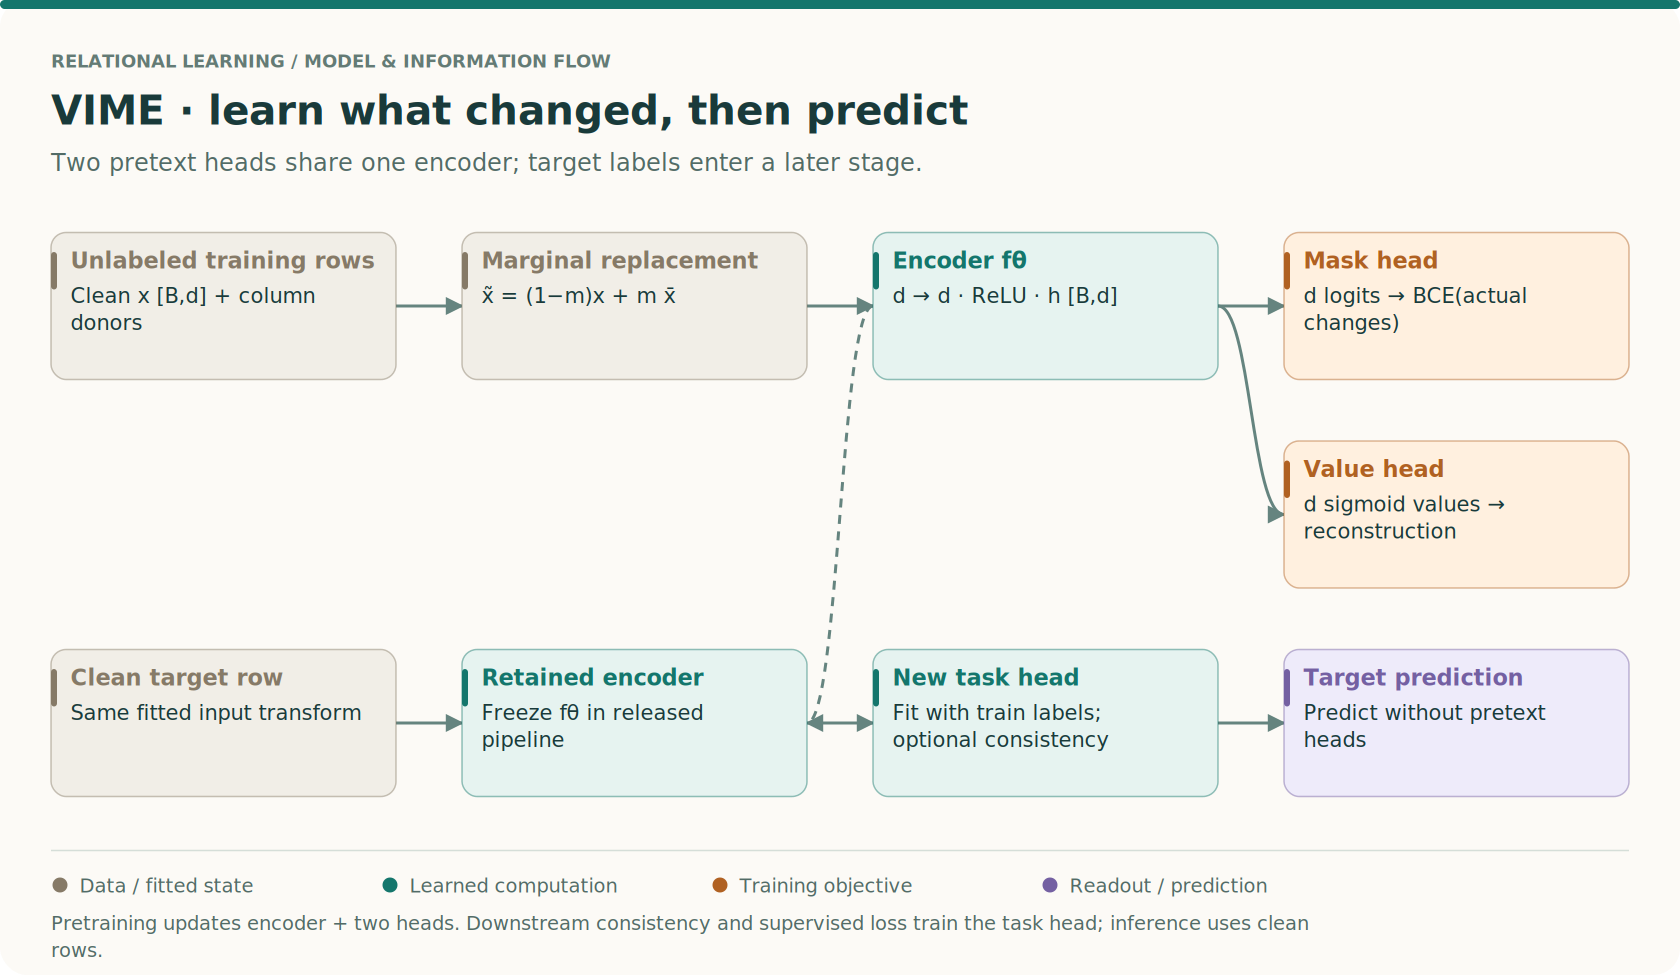</div><figcaption>Read the arrows as data dependencies. Teal: learned computation; amber: training objective; violet: readout or prediction. This is a computation overview; exact settings and paper/release differences are specified below.</figcaption></figure>

### Read the paper with a concrete question

Read the VIME paper's self-supervised and semi-supervised method sections, then compare its equations with the pinned implementation linked below. On your sketch, put a box around **what the model is allowed to observe**. The encoder receives the corrupted row; the original row and corruption target are available to the loss. If the original row were also supplied to the encoder, reconstruction could become a trivial copy operation. [VIME, primary paper](https://proceedings.neurips.cc/paper/2020/hash/7d97667a3e056acab9aaf653807b4a03-Abstract.html).

### Trace one example through both objectives

1. **Choose a row and a donor.** Let x=[0.2,0.8,0.8], donor=[0.9,0.8,0.1], and selected positions m=[1,1,0]. Replacement produces x̃=[0.9,0.8,0.8]. Position 1 was selected but did not change. The released utility's actual-change target is [1,0,0].
2. **Encode once.** The same h=f(x̃) feeds two different learned heads. A gradient from either head can change f. Two heads do not mean two independent encoders.
3. **Score the change detector.** If its probabilities are [0.8,0.2,0.1], binary cross-entropy averages −log(0.8), −log(0.8), and −log(0.9), giving about 0.1839. This objective rewards detecting corruption, not predicting the downstream class.
4. **Score value recovery.** If the reconstruction is [0.3,0.7,0.8], mean squared error across all three coordinates is (0.01+0.01+0)/3=0.006667. With α=2, the total pretext loss is about 0.1972. Writing the reduction explicitly prevents an accidental factor-of-three change.
5. **Transfer the useful part.** Keep f, discard both pretext heads, and attach the task predictor. The released pipeline freezes f; updating it is a different fine-tuning condition. At prediction time the input is a clean row and neither pretext target is needed.

<details><summary>Before revealing: can pretext loss fall while classification gets worse?</summary><p>Yes. The representation may become better at reconstructing high-variance nuisance features or detecting corruption artifacts without retaining the features needed for the class. Measure target performance against the same supervised architecture and label budget; pretext loss alone cannot establish transfer.</p></details>

**Your intermediate artifact:** draw three arrows leaving h: the two temporary training heads and the later task route. Label which parameters each loss updates. Then change the donor's second coordinate to 0.4 and recompute the mask target before starting the notebook.

<!-- depth-walkthrough:end -->



## 1. Learn from features before asking for labels

> **In plain terms.** Hide some information in a row and ask a network to recover it. The original row supplies the training answer, so this stage needs no task labels.

**A feature** is one input measurement, such as a balance or pixel intensity. A row contains d features. **A label** is the outcome we want to predict. In the local lab the label is a digit class, from 0 to 9.

**Self-supervised learning** constructs targets from the inputs themselves. A **pretext task** is this constructed learning problem. An **encoder** is a learned function e that maps a row x to a vector z of hidden features. A **head** maps z to a particular output. The encoder can serve a later task with a new head.

VIME stands for **Value Imputation and Mask Estimation**. Its pretraining stage has two heads: one reconstructs the original values, and one estimates which values were corrupted. Both heads train the same encoder. See [Yoon et al., §4.1 and Figure 1](https://proceedings.neurips.cc/paper/2020/file/7d97667a3e056acab9aaf653807b4a03-Paper.pdf).

**Semi-supervised learning** uses labeled and unlabeled rows while training the downstream predictor. VIME's semi-supervised extension asks the predictor to agree across several corrupted versions of an unlabeled row. It adds a distinct objective after encoder pretraining.

> **Scope check.** Successful reconstruction does not establish that the representation helps the task label. Pretraining can emphasize frequent feature patterns that are irrelevant to the target. A downstream comparison is required.



## 2. Corrupt a value with another value from its column

### Preserve each column's range while breaking relationships

A **marginal distribution** describes one column without conditioning on the others. An **empirical marginal** is the distribution of that column's observed values. VIME draws replacements from the same column. A donor for one column can come from a different row than the donor for the next column.

For each coordinate j, draw m_j from a Bernoulli distribution: it equals 1 with probability p and 0 otherwise. Draw a donor value x̄_j from column j. Construct

`x̃_j = (1 − m_j) x_j + m_j x̄_j`.

The tilde marks a corrupted row; the bar marks donor values. Multiplication is coordinate by coordinate. The encoder sees x̃ alone. The original x and the mask target supervise its outputs; they are not extra encoder inputs.

The released implementation constructs donors with **independent column permutations**. A permutation rearranges existing row indices. This allows self-donors and repeated values. It preserves the donor column's exact multiset of values; the final partially replaced column need not preserve its exact empirical counts in one draw. Across draws, replacement follows the empirical marginal. See the [pinned corruption function](https://github.com/jsyoon0823/VIME/blob/996c58cf4c570061b30c38ecf2a754a9af85aafd/vime_utils.py).

### Worked example: selected and changed are different

Take x = [0.2, 0.8, 0.8], donors [0.9, 0.8, 0.1], and selected mask m = [1, 1, 0]. The corrupted row is [0.9, 0.8, 0.8]. Column 2 was selected but received 0.8 again. Its value did not change.

The paper's equations use the sampled mask m. The release recomputes its supervised target as `m_changed = (x != x̃)`, giving [1, 0, 0]. This lesson's implementation follows the release and names the target explicitly. Predict the result before toggling a coordinate below.



<figure><div class="figure-scroll" style="max-width:100%;overflow-x:auto" tabindex="0" role="region" aria-label="Scrollable computation figure">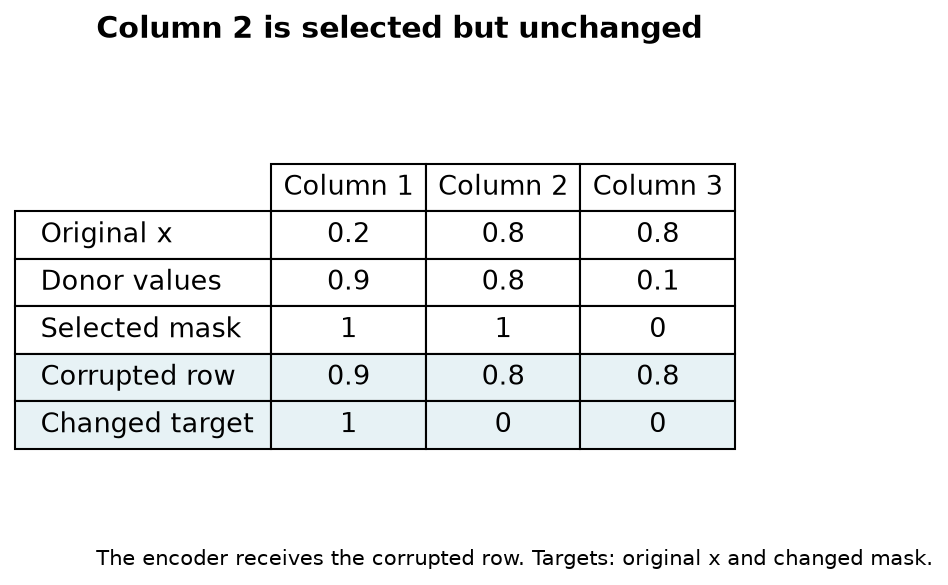</div><figcaption>Computed illustrative trace: sampled mask [1,1,0] produces actual-change target [1,0,0]. The second donor repeats the original value. On narrow screens, scroll the figure horizontally.</figcaption></figure>

**How often can this happen?** Suppose a categorical column has proportions q₁, …, q_r. For a randomly drawn row and an independently sampled donor from the empirical marginal, the collision probability is the sum of q_c². The expected changed fraction is therefore `p × (1 − Σ q_c²)`. A constant column has zero actual changes, even at p = 1. A balanced binary column changes at expected rate p/2. A finite permutation creates dependence across rows, but each donor index is marginally uniform, so this expectation still applies to the average over rows.

**Why this can teach structure.** If two columns usually agree, replacing one can create a mismatch. The encoder can use the other column to detect and repair it. When independent columns carry no such predictive relationship, detecting a replacement from a matching marginal is intrinsically difficult. Detection becomes uncertain; a perfect mask predictor is not always possible.

**Failure case.** Valid individual values can still make an implausible row together. Marginal replacement preserves column-level support, not joint constraints or the true label. This matters especially when using corrupted rows for downstream consistency.



## 3. Model architecture: follow one row end to end

> **In plain terms.** One shared hidden vector feeds two training heads. After pretraining, keep the encoder and replace those heads with a task predictor.

<figure><div class="figure-scroll" style="max-width:100%;overflow-x:auto" tabindex="0" role="region" aria-label="Scrollable computation figure">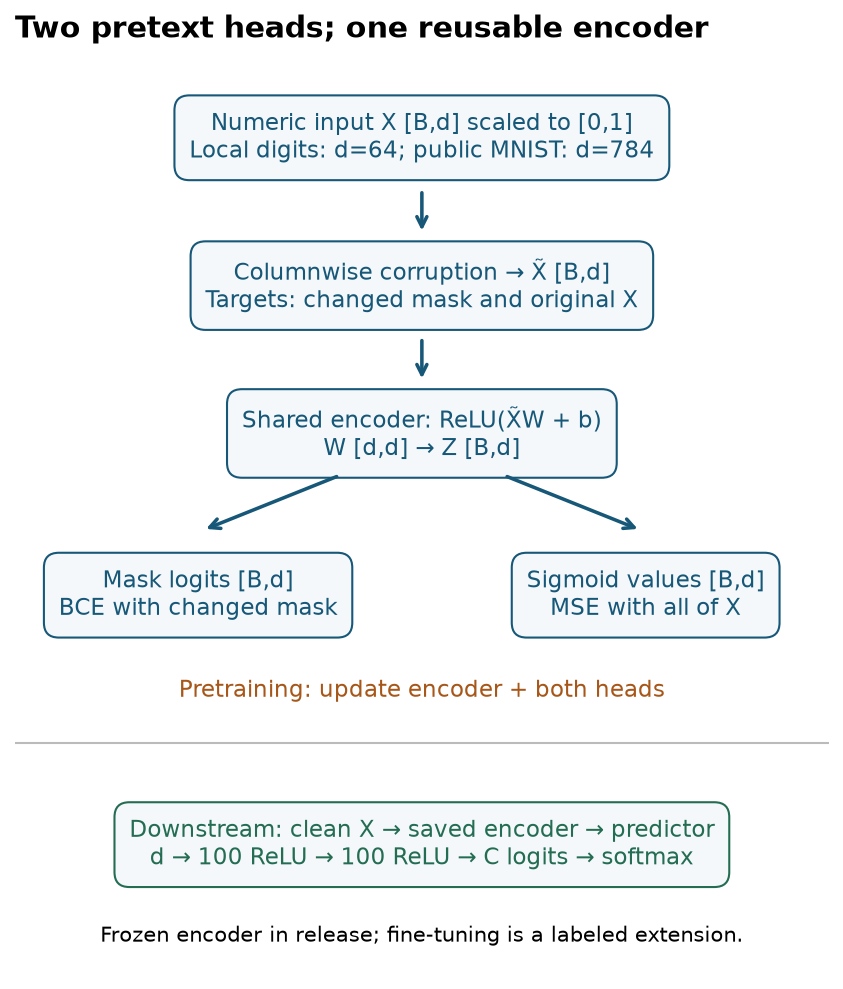</div><figcaption>Numeric released-example architecture. Pretraining updates the encoder and two heads. At prediction time, clean rows pass through the retained encoder and a task head; local fine-tuning is explicitly separate from frozen transfer. On narrow screens, scroll the figure horizontally.</figcaption></figure>

**Pictured variant.** The numeric-data encoder and pretext heads follow the released MNIST example. The local lab uses d = 64 features from sklearn's 8×8 digits, scaled by the known maximum intensity 16. This is a smaller, different dataset from 28×28 MNIST. B denotes the number of rows in a batch. C = 10 is the number of task classes. The saved encoder expects the same d columns in the same order and with the same preprocessing. This experiment trains a separate encoder for this fixed schema.

1. Corrupt a normalized matrix X of shape B×d. Produce X̃ of the same shape.
2. Compute `Z = ReLU(X̃ W_e + b_e)`, with W_e of shape d×d and b_e of length d. ReLU replaces each negative number by zero. Z has shape B×d. The PyTorch linear layer stores the transposed weight convention.
3. The mask head produces d **logits** per row. A logit is an unbounded score converted to a probability by `sigmoid(a) = 1/(1+exp(−a))`. The loss combines this transformation with binary cross-entropy for numerical stability.
4. The feature head maps Z to d sigmoid outputs, one reconstructed numeric value per column. The sigmoid restricts these outputs to [0,1], matching the lab's scaled inputs.
5. Backpropagation computes loss derivatives through both heads into the shared encoder. An optimizer uses these derivatives to change its weights. The two heads can favor different representations; the loss weights control their relative influence.
6. For downstream prediction, send the clean row through the encoder, then two 100-unit ReLU layers and a C-logit output layer. Softmax converts the C logits to class probabilities whose sum is one. Only this encoder-plus-predictor path is needed at inference. For class c with logit a_c, softmax assigns `exp(a_c) / Σ_k exp(a_k)`. Task cross-entropy is the negative logarithm of the probability assigned to the observed class, averaged over labeled rows.

The released `vime_self.py` uses a single hidden encoder layer of width d. The paper's [supplement §5](https://proceedings.neurips.cc/paper/2020/file/7d97667a3e056acab9aaf653807b4a03-Supplemental.pdf) explores broader architectures and tuning. A checked small network does not cover that search.

### Frozen transfer and fine-tuning answer different questions

A **frozen encoder** keeps all pretrained encoder parameters fixed. Only the new task head learns. This is how the released downstream pipeline uses `encoder.predict`.

**Fine-tuning** also updates encoder parameters with the task loss. It asks whether pretraining supplies a useful initialization. The curriculum calls for this comparison, so the lab includes it as an explicit extension. It records encoder parameter changes to verify that frozen and fine-tuned paths behave as declared.

**The scratch control** uses the same encoder-plus-head architecture, but starts with random encoder weights and learns only from task labels. Its task head, supervised batch sequence, validation rows and epoch budget match the fine-tuning arm. Pretraining adds computation and unlabeled-data access; the experiment matches labeled resources, not total compute.

> **Scope check.** The paper lists a two-layer perceptron as its supervised-only baseline. Our scratch control retains the additional randomly initialized encoder layer to match the pretrained arm's capacity. It is a controlled initialization comparison, not a reimplementation of that baseline row.



## 4. Derive the two pretext losses

### Mask estimation: assign probability to each actual-change target

> **In plain terms.** Penalize a confident mask prediction when it assigns low probability to the correct target bit.

Let t_j be the actual-change target and q_j the predicted change probability. For one row,

`L_mask = −(1/d) Σ_j [t_j log(q_j) + (1−t_j) log(1−q_j)]`.

Here log is the natural logarithm and Σ adds the d coordinate terms. If t_j = 1, only −log(q_j) remains. If t_j = 0, only −log(1−q_j) remains. Average again over B rows in a batch. Each coordinate contributes equally.

**Worked example.** Target [1,0,0] and predicted probabilities [0.7,0.2,0.1] give terms [0.3567,0.2231,0.1054]. Their mean is approximately 0.2284. These are illustrative predictions, not trained-model outputs.

### Value reconstruction: recover the entire original row

Let r_j be the reconstruction. The numeric reconstruction objective is

`L_value = (1/d) Σ_j (r_j − x_j)²`.

For x = [0.2,0.8,0.8] and r = [0.3,0.7,0.6], squared errors are [0.01,0.01,0.04]. Their mean is 0.02. **Every coordinate contributes**, including both unchanged coordinates. Multiplying the loss by the mask would define a different objective.

Combine the losses as `L_pretrain = L_mask + α L_value`. The scalar α controls the reconstruction weight; α = 2 gives `0.2284 + 2×0.02 = 0.2684` in the worked example. The implementation uses mean reductions in both terms, so changing d does not by itself multiply one term's weight.

<figure><div class="figure-scroll" style="max-width:100%;overflow-x:auto" tabindex="0" role="region" aria-label="Scrollable computation figure">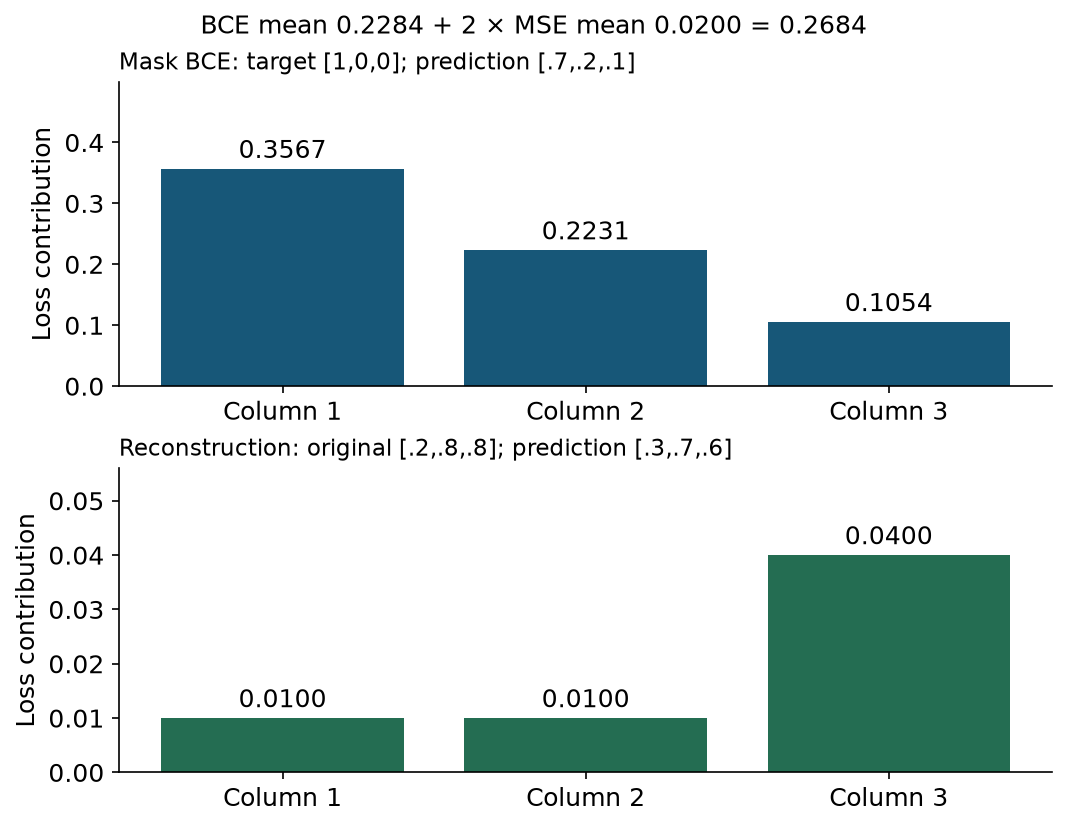</div><figcaption>Computed illustrative loss contributions. BCE mean 0.2284 + 2 × full-coordinate MSE mean 0.0200 = 0.2684. These are hand-chosen predictions, not model scores. On narrow screens, scroll the figure horizontally.</figcaption></figure>

**A misleading diagnostic.** If only 15% of cells actually change, always predicting unchanged gives 85% mask accuracy. Compare the loss and predictions with this constant baseline before claiming mask detection is good. The training loss alone also cannot establish generalization because it uses the fixed corruption bank.

**Why two heads?** Reconstruction encourages recovery of original content. Mask estimation encourages recognizing inconsistent combinations. Removing mask loss creates the lab's reconstruction-only ablation. Comparing it with dual-task pretraining tests whether the extra objective helps under this particular protocol.

**Categorical features.** A category is a discrete alternative with no meaningful numerical distance between its arbitrary ID codes. The paper describes categorical reconstruction with cross-entropy. A mixed-type extension needs an appropriate categorical output distribution and masking convention per feature. The supplied lab handles scaled numeric inputs only; applying its MSE directly to category IDs would impose an arbitrary geometry.

**Boundary predictions.** At p = 0, reconstruction becomes ordinary autoencoding and every mask target is zero. At p = 1, selected replacements can still collide, and little original information may remain. The lab fixes p = 0.3 in advance. Tuning p against the test curve would spend test information.



## 5. Add semi-supervised consistency carefully

Create K independently corrupted views of the same unlabeled batch. Each has shape B×d. Pass each through the frozen encoder and trainable predictor to obtain logits A with shape K×B×C. A **view** is one such corruption of the original examples; row i must refer to the same original row across all K views.

The released [vime_semi.py](https://github.com/jsyoon0823/VIME/blob/996c58cf4c570061b30c38ecf2a754a9af85aafd/vime_semi.py) computes

`L_consistency = mean_(i,c) [ (1/K) Σ_k (A_kic − mean_k A_kic)² ]`.

The divisor is K, not K−1: this is population variance over generated views. With K = 1 it is zero. Compute variance across the **view axis**, then average rows and classes. Variance across rows would instead push different examples toward a common answer.

The predictor objective is `L_task + β L_consistency`. The task term is cross-entropy on labeled clean rows. β controls consistency strength. The release measures consistency on logits, before softmax; replacing them with probabilities changes the objective and its scale.

### Worked example: clean-reference loss and view variance

For one output coordinate, take augmented logits 0.2 and 0.6. Their mean is 0.4. View variance is `[(0.2−0.4)²+(0.6−0.4)²]/2 = 0.04`.

The paper's Eqs. 9–10 write squared difference from the clean prediction. If its value is 0.8, that loss is `[(0.2−0.8)²+(0.6−0.8)²]/2 = 0.20`. For any fixed clean value c,

`mean_k (a_k−c)² = variance_k(a_k) + (mean_k(a_k)−c)²`.

Expand each difference as `(a_k−mean(a)) + (mean(a)−c)`. The cross-term sums to zero because deviations from the mean sum to zero. The two objectives coincide only when the clean value equals the mean of the augmented predictions. This algebra applies to the same output coordinate and representation; switching between logits and probabilities introduces a further difference.



**Failure case.** If corruption removes the feature that determines the true class, demanding unchanged predictions can suppress useful task information. Small consistency loss alone is weak evidence: a constant predictor has zero view variance. Always measure supervised task performance too.

> **Scope check.** The lab implements the release's frozen-encoder, logit-variance path. It does not silently identify that objective with the paper's clean-reference equation.



## 6. Measure label efficiency with an information budget

> **In plain terms.** Give paired models the same labels and test examples. Let only the declared pretraining procedure change.

A **label-efficiency curve** plots downstream performance against the number of labels made available for fitting and choosing the model. The x-axis here counts both gradient-training labels and validation labels. An **epoch** is one pass over the designated training rows. **Validation** chooses the best epoch by cross-entropy. **Test accuracy** is the fraction of held-out rows whose largest-probability class equals their label.

The offline dataset has 1,797 rows and 64 numeric features. Each seed reserves 25% (450 rows) for testing. Of the remaining 1,347, 60% (809 rows) form the fixed unlabeled pool; 538 form the label reserve. No test or validation row enters self-supervised training. Unused reserve rows remain unused.

We choose nested, class-balanced labeled subsets of 50, 150 and 500 rows. Each budget uses 80% for gradient updates and 20% for validation: 40/10, 120/30 and 400/100. The selected sets are nested; the train/validation assignment is resampled within each budget. Thus cross-budget differences include that reassignment. Benchmark labels are used to stratify splits; the learner receives labels only for its designated labeled subset.

<figure><div class="figure-scroll" style="max-width:100%;overflow-x:auto" tabindex="0" role="region" aria-label="Scrollable computation figure">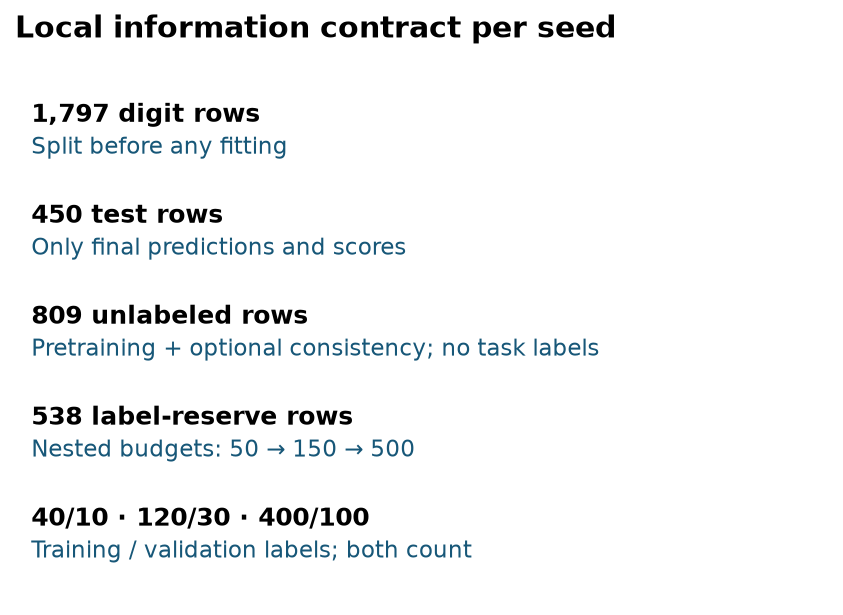</div><figcaption>Local digits protocol per seed. Test rows are excluded from pretraining, validation, and donor pools. Validation labels count toward each labeled budget. On narrow screens, scroll the figure horizontally.</figcaption></figure>

| Arm | Encoder initialization | Downstream encoder | Unlabeled task loss |
|---|---|---|---|
| scratch | Random | Updated | None |
| vime_finetune | Mask + value pretraining | Updated | None |
| vime_frozen | Mask + value pretraining | Frozen | None |
| recon_finetune | Value pretraining only | Updated | None |
| vime_semi | Mask + value pretraining | Frozen | Logit view variance |

**Held fixed.** Paired arms share labels, validation rows, test rows, encoder/head dimensions, head initialization, supervised batch order, and 60 downstream epochs. Self-supervised arms use 30 epochs on the same unlabeled pool. Pretraining uses one fixed corrupted bank, matching the source; semi-supervised views are regenerated. Learning rates and loss weights are declared in advance. There is no hyperparameter search.

**Varied.** Whether the encoder is pretrained, whether mask estimation contributes, whether the encoder is frozen, and whether downstream consistency is present. Use the specific arm pair that isolates your question: dual versus reconstruction-only fine-tuning isolates mask loss; frozen versus fine-tuned VIME changes adaptation; frozen VIME-self versus VIME-semi adds consistency.



### Author-run evidence

**Measured test accuracy, mean ± sample SD over three seeds (%).** These are author-reference outputs, not your current notebook run.

| Total labels | Scratch | VIME fine-tune | VIME frozen | Reconstruction fine-tune | VIME semi |
|---|---|---|---|---|---|
| 50 | 77.70 ± 4.17 | 76.07 ± 2.96 | 74.00 ± 1.11 | 77.41 ± 1.22 | 76.44 ± 2.62 |
| 150 | 87.48 ± 2.81 | 85.19 ± 2.48 | 82.74 ± 2.90 | 85.11 ± 2.73 | 84.74 ± 2.38 |
| 500 | 93.56 ± 0.80 | 92.44 ± 1.90 | 89.19 ± 1.22 | 93.04 ± 1.86 | 91.04 ± 1.56 |

**Paired fine-tuning gains (percentage points).**

- 50 total labels: -2.89, -0.44, -1.56; mean -1.63.
- 150 total labels: -2.00, -3.78, -1.11; mean -2.30.
- 500 total labels: +0.00, -1.11, -2.22; mean -1.11.

**Observed conclusion.** Under this fixed digits recipe, fine-tuned VIME has lower mean accuracy than scratch at all three budgets. The paired gains above show the size and seed variability. This does not establish that VIME cannot help other datasets or protocols.


<figure><div class="figure-scroll" style="max-width:100%;overflow-x:auto" tabindex="0" role="region" aria-label="Scrollable computation figure">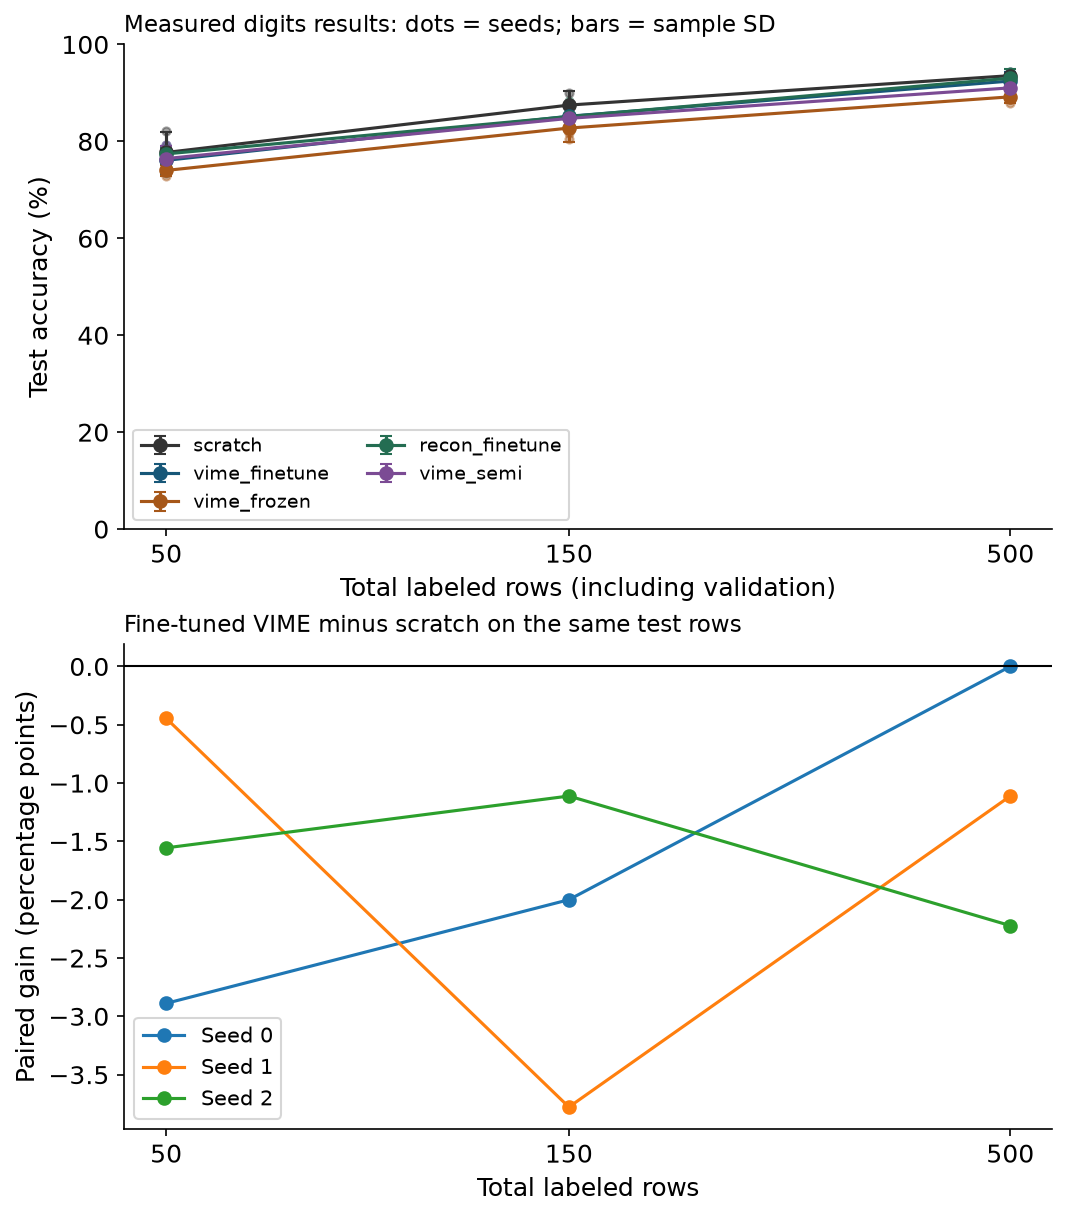</div><figcaption>Author-run evidence on offline digits. Every point is a fresh fit; bars show sample SD over three paired split/initialization seeds. The lower plot preserves each paired fine-tuning gain. No original-paper score is plotted. On narrow screens, scroll the figure horizontally.</figcaption></figure>

The figure shows each seed and means with sample standard-deviation bars. For each budget, the **paired gain** is fine-tuned accuracy minus scratch accuracy on that seed's shared test rows. Report all three differences, even when their signs disagree. Standard deviation summarizes this small set of split/initialization repetitions; it is not a confidence interval over new datasets.

> **Scope check.** This is one small image-derived table, with a fixed limited training recipe. Seeds do not create independent datasets. No general tabular winner, clinical claim, or relational benefit follows from this curve. The data, architecture search, labeled/unlabeled ratios, optimizer implementation and repetitions differ from the paper; paper-table comparability is **INCOMPARABLE**.

### Paper claim, checked code, local measurement

The paper evaluates label efficiency and downstream prediction across several domains (§5). Its public-data experiments include MNIST treated as 784 tabular features, Income and Blog. The supplement specifies a 10% labeled / 90% unlabeled split of the public training sets and retains their separate test sets.

**A concrete paper target.** Table 2 reports the following MNIST accuracies (mean ± standard deviation over ten runs): supervised-only 93.87 ± 0.14%, self-supervised-only 94.06 ± 0.19%, and full VIME 95.77 ± 0.22%. The reported self-only improvement is 0.19 percentage points; full VIME adds 1.90 points over supervised-only. These are published results on 784-feature MNIST, not measurements from this lab. [Source: Table 2](https://proceedings.neurips.cc/paper/2020/file/7d97667a3e056acab9aaf653807b4a03-Paper.pdf).

> **Scope check.** A digits accuracy near one of these numbers is still INCOMPARABLE. The follow-up must align data, labeled/unlabeled allocation, selection, architecture and baseline definitions before numerical agreement is evidence of reproduction.

The source audit pins commit `996c58cf4c570061b30c38ecf2a754a9af85aafd`. It checks exact corruption outputs against the original NumPy function on a fixture containing donor collisions. This establishes that tested operation. It does not establish historical training parity: the release uses Keras/TensorFlow, while this lab uses PyTorch and different initialization/optimizer defaults.

See [source identities](../labs/_sources_l071.json), [local evidence](../labs/_verify_l071_results.json), and the [reproduction contract](../labs/l071-reproduction.md). The [MNIST access check](../labs/_mnist_access_l071_results.json) verifies the public archive against Keras's official SHA-256 and checks its shapes and scaling. Public MNIST follow-up training is **NOT_RUN** at package creation. Restricted genomic/clinical data, the full baseline set, and original tuning remain outside this artifact's demonstrated evidence.



## 7. Lab: implement, check, explain

The companion notebook exposes the full encoder, both heads, pretraining loop and downstream trainer. You implement three operations used by the actual training loop: columnwise corruption with actual-change targets, full-coordinate pretext loss, and view-axis consistency loss. Each has a numeric CHECK that catches a plausible wrong implementation.

**Before running:** predict which coordinate in the collision fixture gets a zero mask target, whether untouched coordinates affect reconstruction loss, and what K = 1 does to consistency.

**EXIT submission:** produce the complete five-arm × three-budget curve; list the three paired fine-tuning gains at each budget; defend whether pretraining helps under the local recipe. Identify validation-label cost, one source/paper discrepancy, and one experiment needed before transferring the conclusion to relational data. A valid result can show no gain.

**Next step after EXIT.** Run the same visible code on public MNIST through the gated Colab cell or the Modal operator. The reproduction contract lists every remaining protocol gap; choosing a larger preset does not remove those gaps. Compare measured results with a specifically named paper experiment only after aligning its dataset, split, metric, model selection and baselines.



Ask the tutor to review your code and your interpretation. Reading or executing the author solution does not establish mastery. Return tomorrow and derive the collision example without notes; next week, reconstruct the split diagram and explain the label budget. Lesson 072 will compare reconstruction-based learning with contrastive and multi-view objectives.



## Primary reading

Read [VIME, §4.1–4.2, Eqs. 3–10 and Figures 1–2](https://proceedings.neurips.cc/paper/2020/file/7d97667a3e056acab9aaf653807b4a03-Paper.pdf), then inspect [the pinned released implementation](https://github.com/jsyoon0823/VIME/tree/996c58cf4c570061b30c38ecf2a754a9af85aafd). Use [supplement §§2, 5–6](https://proceedings.neurips.cc/paper/2020/file/7d97667a3e056acab9aaf653807b4a03-Supplemental.pdf) to distinguish the example architecture from the paper's experimental search. The [printable reference](../reference/0071-vime-masked-tabular-ssl.html) collects the equations and evidence boundaries.



## Paper reproduction track

The [paper reproduction section](../labs/html/0071-vime-masked-tabular-ssl.html#paper-reproduction) in the companion notebook includes the full runnable paper/release implementation after EXIT, separately from its compact teaching experiment. Read the [reproduction guide](../labs/reproductions/README.md) for the named target, full-data commands, source pins and remaining gaps. The full model and training code are visible in the notebook. Smoke execution and source equivalence are checks; published-result reproduction requires the aligned experiment and its measured comparison.


<a id="lab-exercises"></a>
## Lab exercises

The author evidence above is a reference. The following cells run your live implementations. Completing these cells must change the functions that the actual training loop calls.

In [ ]:
# PROVIDED: dependencies
import copy, hashlib, json, platform, time
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.nn import functional as F
from sklearn.datasets import load_digits
from sklearn.metrics import accuracy_score, log_loss
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
torch.set_num_threads(1)

### TODO · corrupt

**Goal:** Return (changed, xt), both [B,d]. donors[i,j] is a row index for column j. Preserve x; define changed by actual value inequality, including donor collisions.

**Why:** this operation is part of the live VIME objective. A plausible wrong answer changes the learning problem.

**Hint boundary:** Eq. 3 and released vime_utils.pretext_generator. Think about independent donor indices per column; do not replace a complete row.

Predict the CHECK outcome before running it.

In [ ]:
def corrupt(x, mask, donors):
    """Return (changed, xt), both [B,d]. donors[i,j] is a row index for column j. Preserve x; define changed by actual value inequality, including donor collisions."""
    # TODO: implement the operation; keep the function signature.
    raise NotImplementedError("corrupt")

In [ ]:
# CHECK: independent numeric fixture
x0=torch.tensor([[0.,1.],[1.,1.]])
donors0=torch.tensor([[1,1],[0,0]])
changed0,xt0=corrupt(x0,torch.ones_like(x0),donors0)
assert torch.equal(xt0,torch.tensor([[1.,1.],[0.,1.]]))
assert torch.equal(changed0,torch.tensor([[1.,0.],[1.,0.]])), 'Collision must have target zero'
assert torch.equal(corrupt(x0,torch.zeros_like(x0),donors0)[1],x0)
print("corrupt: CHECK passed")

### TODO · pretext_loss

**Goal:** Return (total, lm, lr): mean BCE from mask logits, mean squared error on every coordinate, and mask_weight*lm + alpha*lr. Preserve gradients.

**Why:** this operation is part of the live VIME objective. A plausible wrong answer changes the learning problem.

**Hint boundary:** Eqs. 4–6. The reconstruction denominator includes unchanged cells. F.binary_cross_entropy_with_logits accepts raw scores.

Predict the CHECK outcome before running it.

In [ ]:
def pretext_loss(mask_logits, reconstruction, x, changed, alpha=2., mask_weight=1.):
    """Return (total, lm, lr): mean BCE from mask logits, mean squared error on every coordinate, and mask_weight*lm + alpha*lr. Preserve gradients."""
    # TODO: implement the operation; keep the function signature.
    raise NotImplementedError("pretext_loss")

In [ ]:
# CHECK: independent numeric fixture
z0=torch.zeros(2,2,requires_grad=True)
x0=torch.tensor([[0.,1.],[1.,1.]])
total0,lm0,lr0=pretext_loss(z0,torch.zeros_like(x0),x0,torch.zeros_like(x0),2.)
assert abs(lm0.item()-np.log(2))<1e-6
assert abs(lr0.item()-.75)<1e-6, 'Use all coordinates, even when changed is zero'
assert abs(total0.item()-(np.log(2)+1.5))<1e-6
total0.backward(); assert z0.grad.abs().sum()>0
print("pretext_loss: CHECK passed")

### TODO · consistency_loss

**Goal:** Input [K,B,C]. Return population variance over augmented views, then average over batch and classes. K=1 must give zero.

**Why:** this operation is part of the live VIME objective. A plausible wrong answer changes the learning problem.

**Hint boundary:** Released vime_semi.py. Identify the view axis before reducing. Avoid the default unbiased sample variance.

Predict the CHECK outcome before running it.

In [ ]:
def consistency_loss(logits):
    """Input [K,B,C]. Return population variance over augmented views, then average over batch and classes. K=1 must give zero."""
    # TODO: implement the operation; keep the function signature.
    raise NotImplementedError("consistency_loss")

In [ ]:
# CHECK: independent numeric fixture
a0=torch.tensor([[[0.,2.]],[[2.,4.]]],requires_grad=True)
assert consistency_loss(a0).item()==1.
assert consistency_loss(a0[:1]).item()==0.
assert consistency_loss(torch.ones(3,2,4)).item()==0.
consistency_loss(a0).backward(); assert a0.grad.abs().sum()>0
print("consistency_loss: CHECK passed")

### PROVIDED · architecture and corruption draws

The pretext encoder is d→d ReLU. Its two heads have d outputs. The predictor copies the encoder; each arm receives a newly initialized, paired task head.

In [ ]:
# PROVIDED: draw_corruption
def draw_corruption(x, p, generator):
    """One independent permutation per column, as in the released source."""
    mask = (torch.rand(x.shape, generator=generator) < p).to(x.dtype)
    donors = torch.stack([torch.randperm(len(x), generator=generator)
                          for _ in range(x.shape[1])], dim=1)
    return corrupt(x, mask, donors)

In [ ]:
# PROVIDED: VIME
class VIME(nn.Module):
    """Released numeric architecture: d→d ReLU encoder; two d-dimensional heads."""
    def __init__(self, d):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(d, d), nn.ReLU())
        self.mask_head = nn.Linear(d, d)
        self.feature_head = nn.Sequential(nn.Linear(d, d), nn.Sigmoid())

    def forward(self, x):
        z = self.encoder(x)
        return self.mask_head(z), self.feature_head(z)

In [ ]:
# PROVIDED: Predictor
class Predictor(nn.Module):
    """Encoder → 100-ReLU → 100-ReLU → C logits. All arms share this shape."""
    def __init__(self, encoder, d, classes):
        super().__init__()
        self.encoder = copy.deepcopy(encoder)
        self.head = nn.Sequential(nn.Linear(d, 100), nn.ReLU(),
                                  nn.Linear(100, 100), nn.ReLU(), nn.Linear(100, classes))

    def forward(self, x):
        return self.head(self.encoder(x))

### PROVIDED · pretraining loop

The corruption bank is created once, as in the release. Follow the calls to your corrupt and pretext_loss functions. The reconstruction-only arm sets mask_weight to zero.

In [ ]:
# PROVIDED: pretrain
def pretrain(x, seed, epochs=30, p=.3, alpha=2., mask_weight=1., device='cpu'):
    """Fixed corruption bank as in vime_self.py; no labels or test rows accepted."""
    torch.manual_seed(seed)
    model = VIME(x.shape[1]).to(device)
    opt = torch.optim.RMSprop(model.parameters(), lr=.001, alpha=.9, eps=1e-7)
    g = torch.Generator().manual_seed(seed + 7100)
    changed, xt = draw_corruption(x.cpu(), p, g)
    x, changed, xt = x.to(device), changed.to(device), xt.to(device)
    history = []
    for epoch in range(epochs):
        losses=[]
        for idx in torch.randperm(len(x), generator=g).split(128):
            idx=idx.to(device)
            ml, xr = model(xt[idx])
            loss, lm, lr = pretext_loss(ml, xr, x[idx], changed[idx], alpha, mask_weight)
            opt.zero_grad(); loss.backward(); opt.step()
            losses.append([loss.item(), lm.item(), lr.item()])
        history.append(np.mean(losses, axis=0).tolist())
    return model.cpu(), {'loss_trace':history, 'actual_change_rate':changed.mean().item(),
                         'sampled_probability':p, 'mask_weight':mask_weight}

### PROVIDED · data and information boundaries

Data labels are used only by the benchmark split designer, and by designated supervised fits. Pixel normalization uses the known measurement range; it estimates no statistic from held-out rows.

In [ ]:
# PROVIDED: make_split
def make_split(y, budgets, seed, external_test=False):
    """No feature-dependent fitting. Nested class-balanced label budgets include validation.

    A fixed 60% of development rows is unlabeled. Remaining rows form the label reserve.
    Original class labels are used ONLY by the benchmark designer to balance selection.
    """
    ids=np.arange(len(y))
    if external_test:
        dev, test = ids, np.array([],dtype=int)
    else:
        dev, test = train_test_split(ids,test_size=.25,stratify=y,random_state=seed)
    reserve, unlab=train_test_split(dev,test_size=.6,stratify=y[dev],random_state=seed+100)
    rng=np.random.default_rng(seed+200)
    buckets=[rng.permutation(reserve[y[reserve]==c]).tolist() for c in np.unique(y)]
    order=[]
    while any(buckets):
        for bucket in buckets:
            if bucket: order.append(bucket.pop())
    result={}
    for b in budgets:
        if b>len(order): raise ValueError('Label budget exceeds reserve')
        selected=np.array(order[:b])
        tr,va=train_test_split(selected,test_size=.2,stratify=y[selected],random_state=seed+300)
        result[b]=(tr,va)
    return {'unlabeled':unlab,'test':test,'budgets':result}

In [ ]:
# PROVIDED: load_data
def load_data(dataset='digits'):
    if dataset=='digits':
        d=load_digits()
        # 16 is the documented measurement range, not an estimated dataset maximum.
        return d.data.astype('float32')/16.,d.target.astype('int64'),None,None
    if dataset=='mnist':
        import urllib.request
        cache=Path.home()/'.cache'/'l071';cache.mkdir(parents=True,exist_ok=True)
        path=cache/'mnist.npz'
        if not path.exists():
            urllib.request.urlretrieve('https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz',path)
        # Archive SHA-256 published by keras/src/datasets/mnist.py.
        if hashlib.sha256(path.read_bytes()).hexdigest()!='731c5ac602752760c8e48fbffcf8c3b850d9dc2a2aedcf2cc48468fc17b673d1':
            raise ValueError('MNIST archive checksum mismatch')
        with np.load(path) as d:
            return (d['x_train'].reshape(-1,784).astype('float32')/255.,d['y_train'].astype('int64'),
                    d['x_test'].reshape(-1,784).astype('float32')/255.,d['y_test'].astype('int64'))
    raise ValueError(dataset)

### PROVIDED · downstream training and validation

Find the requires_grad switch, the call to your consistency_loss, and the best-validation-state restoration. Test features and labels cannot enter this function.

In [ ]:
# PROVIDED: fit_predictor
def fit_predictor(encoder, x, y, xv, yv, xu, seed, epochs=60, frozen=False, beta=0., K=3, device='cpu'):
    """Select by validation cross-entropy; test arrays cannot enter this function.

    The same supervised batches and head initialization are used across paired arms.
    """
    torch.manual_seed(seed+1000)
    model=Predictor(encoder,x.shape[1],int(max(y.max(),yv.max()).item())+1).to(device)
    for parameter in model.encoder.parameters(): parameter.requires_grad_(not frozen)
    before={k:v.detach().clone() for k,v in model.encoder.state_dict().items()}
    opt=torch.optim.Adam([p for p in model.parameters() if p.requires_grad],lr=.001)
    g=torch.Generator().manual_seed(seed+2000)
    ug=torch.Generator().manual_seed(seed+3000)
    x,y,xv,yv=x.to(device),y.to(device),xv.to(device),yv.to(device)
    best_loss=float('inf'); best=None; chosen=0
    for epoch in range(epochs):
        model.train()
        for idx in torch.randperm(len(x),generator=g).split(64):
            idx=idx.to(device)
            loss=F.cross_entropy(model(x[idx]),y[idx])
            if beta:
                ux=xu[torch.randperm(len(xu),generator=ug)[:64]]
                views=torch.stack([draw_corruption(ux,.3,ug)[1] for _ in range(K)])
                logits=model(views.to(device))
                loss=loss+beta*consistency_loss(logits)
            opt.zero_grad();loss.backward();opt.step()
        model.eval()
        with torch.no_grad(): value=F.cross_entropy(model(xv),yv).item()
        if value<best_loss:
            best_loss=value;chosen=epoch+1;best=copy.deepcopy(model.state_dict())
    model.load_state_dict(best)
    delta=sum((v-before[k]).abs().sum().item() for k,v in model.encoder.state_dict().items())
    return model.cpu(),{'best_epoch':chosen,'validation_loss':best_loss,'encoder_delta':delta}

### PROVIDED · matched experiment

The loop holds splits and head seeds fixed across arms. Inspect each arm tuple. A model is selected before its test predictions are computed.

In [ ]:
# PROVIDED: summarize
def summarize(records):
    rows=[]
    for budget in sorted({r['budget'] for r in records}):
        scratch={r['seed']:r['accuracy'] for r in records if r['budget']==budget and r['arm']=='scratch'}
        for arm in sorted({r['arm'] for r in records}):
            rr=[r for r in records if r['budget']==budget and r['arm']==arm]
            scores=[r['accuracy'] for r in rr]
            gaps=[r['accuracy']-scratch[r['seed']] for r in rr]
            rows.append(dict(budget=budget,arm=arm,accuracy=float(np.mean(scores)),
                             sd=float(np.std(scores,ddof=1)) if len(scores)>1 else None,
                             paired_gain=float(np.mean(gaps)),seed_gains=gaps))
    return rows

In [ ]:
# PROVIDED: run_experiment
def run_experiment(seeds=(0,1,2),budgets=(50,150,500),pre_epochs=30,epochs=60,dataset='digits',device='cpu'):
    torch.set_num_threads(1)
    start=time.time()
    X,Y,Xtest,Ytest=load_data(dataset)
    x=torch.from_numpy(X);y=torch.from_numpy(Y)
    records=[];splits=[];pretexts=[]
    for seed in seeds:
        split=make_split(Y,budgets,seed,external_test=Xtest is not None)
        u=split['unlabeled'];xu=x[u]
        vime,trace=pretrain(xu,seed,pre_epochs,device=device)
        recon,rtrace=pretrain(xu,seed,pre_epochs,mask_weight=0.,device=device)
        torch.manual_seed(seed);random=VIME(x.shape[1])
        pretexts.append(dict(seed=seed,vime=trace,reconstruction=rtrace))
        split_record={'seed':seed,'unlabeled':u.tolist(),'test':split['test'].tolist(),'budgets':{}}
        for budget in budgets:
            tr,va=split['budgets'][budget]
            split_record['budgets'][str(budget)]={'train':tr.tolist(),'validation':va.tolist()}
            for arm,enc,frozen,beta in [('scratch',random.encoder,False,0.),
                                       ('vime_finetune',vime.encoder,False,0.),
                                       ('vime_frozen',vime.encoder,True,0.),
                                       ('recon_finetune',recon.encoder,False,0.),
                                       ('vime_semi',vime.encoder,True,1.)]:
                model,info=fit_predictor(enc,x[tr],y[tr],x[va],y[va],xu,seed,
                                         epochs,frozen,beta,device=device)
                tx=x[split['test']] if Xtest is None else torch.from_numpy(Xtest)
                ty=Y[split['test']] if Ytest is None else Ytest
                with torch.no_grad(): probs=model(tx).softmax(-1).numpy()
                records.append(dict(seed=seed,budget=budget,train_labels=len(tr),validation_labels=len(va),
                                    unlabeled_rows=len(u),arm=arm,accuracy=float(accuracy_score(ty,probs.argmax(1))),
                                    log_loss=float(log_loss(ty,probs)),**info))
        splits.append(split_record)
    return dict(dataset=dataset,config=dict(seeds=list(seeds),budgets=list(budgets),pre_epochs=pre_epochs,epochs=epochs,
                p=.3,alpha=2.,beta=1.,K=3,device=device),records=records,summary=summarize(records),
                pretexts=pretexts,splits=splits,data_sha256=hashlib.sha256(X.tobytes()+Y.tobytes()).hexdigest(),
                environment=dict(python=platform.python_version(),torch=torch.__version__,numpy=np.__version__),
                seconds=time.time()-start,verdict='INCOMPARABLE',
                scope='Local label-efficiency experiment; no paper-table reproduction. Seeds are not datasets.')

### RUN · your label-efficiency curve

Hold p=0.3, alpha=2, epochs and seeds fixed. Do not change them after looking at test scores. Predict the sign of the fine-tuning gain at 50 and 500 total labels. A lower pretext loss alone cannot settle that prediction.

In [ ]:
# Verify the trainer resolves YOUR functions, then run fresh fits.
assert draw_corruption.__globals__['corrupt'] is corrupt
assert pretrain.__globals__['pretext_loss'] is pretext_loss
assert fit_predictor.__globals__['consistency_loss'] is consistency_loss
result = run_experiment()
summary = pd.DataFrame(result['summary'])
display(summary[['budget','arm','accuracy','sd','paired_gain']])
Path('l071-student-results.json').write_text(json.dumps(result,indent=2))

In [ ]:
# PROVIDED: plot fresh results from this kernel
fig, ax = plt.subplots(figsize=(8,5))
for arm, rows in summary.groupby('arm'):
    line=ax.errorbar(rows.budget,100*rows.accuracy,yerr=100*rows.sd,marker='o',capsize=3,label=arm)
    for r in result['records']:
        if r['arm']==arm: ax.scatter(r['budget'],100*r['accuracy'],s=12,alpha=.4,color=line[0].get_color())
ax.set(xscale='log',xticks=[50,150,500],xticklabels=[50,150,500],ylim=(0,100),xlabel='Total labeled rows including validation',ylabel='Test accuracy (%)')
ax.legend(); ax.set_title('Fresh kernel output: points and sample SD across seeds'); plt.show()

### EXIT · defend the measured claim

Submit all 45 fitted results, the three paired fine-tuning gains at each budget, and a written interpretation. State what your comparison holds fixed and what it cannot establish. Include one donor-collision example and one paper/code discrepancy. Paste your conclusion to the tutor for review; the structural CHECK below does not grade understanding.

In [ ]:
# EXIT: completeness and information-boundary checks
assert len(result['records'])==45
assert len({(r['seed'],r['budget'],r['arm']) for r in result['records']})==45
assert all(r['train_labels']+r['validation_labels']==r['budget'] for r in result['records'])
assert all(r['encoder_delta']==0 for r in result['records'] if r['arm'] in ['vime_frozen','vime_semi'])
assert all(r['encoder_delta']>0 for r in result['records'] if r['arm'] in ['scratch','vime_finetune','recon_finetune'])
for s in result['splits']:
    u=set(s['unlabeled']); test=set(s['test'])
    for b in s['budgets'].values():
        tr=set(b['train']); va=set(b['validation'])
        assert not tr&va and not (tr|va)&u and not (tr|va|u)&test
for row in result['summary']:
    if row['arm']=='vime_finetune': print(row['budget'], 'paired gains (pp):', np.round(100*np.array(row['seed_gains']),2))
print('Structural EXIT passed. Written interpretation still requires review.')

**Your conclusion:** write 150–250 words addressing direction and variability of the gains, validation-label cost, fine-tuning versus frozen transfer, and why these results are INCOMPARABLE with the paper tables. Propose one useful ablation before generalizing to relational data.

### Optional teaching extension · public MNIST follow-up

The same visible training functions can run on 28×28 MNIST. Select a GPU runtime before enabling this cell. It downloads and checks the public archive. The larger run still differs from the original protocol: fixed architecture, 60/40 unlabeled/reserve split, limited budgets and different framework. Full paper reproduction remains unestablished. For unattended execution use `modal run --detach modal/l071_paper_repro.py --preset closer` from the repository root. See [the contract](../labs/l071-reproduction.md).

In [ ]:
RUN_TEACHING_EXTENSION = False
if RUN_TEACHING_EXTENSION:
    device='cuda' if torch.cuda.is_available() else 'cpu'
    followup=run_experiment(dataset='mnist',seeds=(0,1,2),budgets=(100,1000,6000),pre_epochs=30,epochs=60,device=device)
    Path('l071-mnist-followup.json').write_text(json.dumps(followup,indent=2))
    display(pd.DataFrame(followup['summary']))
    print('Verified here: public MNIST controlled fits. Paper claim: cited. Verdict: INCOMPARABLE.')
else:
    print('MNIST scale-up: NOT_RUN; original paper-table reproduction: INCOMPARABLE.')

<a id="paper-reproduction"></a>
## Paper reproduction · implementation, protocol, and measured comparison

**Target:** VIME Table 2 MNIST, 6000 labeled / 54000 unlabeled / 10000 test rows. The original TensorFlow/Keras model and trainer below run in a separate Python 3.7 environment. It preserves the released initialization, optimizers, frozen transfer, fixed corruption bank, and 1000-step semi-supervised schedule. Ten declared seeds and all three released MLP arms are recorded.

**Unresolved paper detail:** the paper selected architectures by validation, but the release only supplies a fixed architecture. This executes the released experiment at the table's label budget; it cannot establish exact Table 2 parity. The code reports that limitation even if a score happens to match. The earlier PyTorch teaching experiment remains useful for interventions.

**Read → predict → run.** Compare each architecture and stopping rule below with the teaching lane. Predict which protocol changes could reverse its ranking. The following PROVIDED cells write the visible source to an isolated `paper-run` folder. The runner imports those exact files, so edits in these cells are the implementation it trains. Run all source cells before enabling the final run. After editing a source chunk, rerun that file’s source cells from the first chunk so append cells do not duplicate definitions. Preserve the pinned copy for parity checks.

**Evidence rule:** a smoke run tests execution and is always INCOMPARABLE. A full run records published targets, measured gaps, source choices and missing details; a small score gap alone does not certify protocol identity. [Reproduction guide](../labs/reproductions/README.md).

In [ ]:
# PROVIDED: isolated files for the visible paper implementation
from pathlib import Path
import sys, subprocess
PAPER_ROOT=Path('paper-run').resolve()
PAPER_ROOT.mkdir(exist_ok=True)

### PROVIDED · sources/vime/data_loader.py

Read the operations used by the reproduction runner. This is executable source, not a link to an unseen model.

In [ ]:
Path('paper-run/sources/vime').mkdir(parents=True,exist_ok=True)

#### imports and module context

In [ ]:
%%writefile paper-run/sources/vime/data_loader.py
"""VIME: Extending the Success of Self- and Semi-supervised Learning to Tabular Domain (VIME) Codebase.

Reference: Jinsung Yoon, Yao Zhang, James Jordon, Mihaela van der Schaar, 
"VIME: Extending the Success of Self- and Semi-supervised Learning to Tabular Domain," 
Neural Information Processing Systems (NeurIPS), 2020.
Paper link: TBD
Last updated Date: October 11th 2020
Code author: Jinsung Yoon (jsyoon0823@gmail.com)
-----------------------------

data_loader.py
- Load and preprocess MNIST data (http://yann.lecun.com/exdb/mnist/)
"""

# Necessary packages
import numpy as np
import pandas as pd
from keras.datasets import mnist



#### load_mnist_data

In [ ]:
%%writefile -a paper-run/sources/vime/data_loader.py
def load_mnist_data(label_data_rate):
  """MNIST data loading.
  
  Args:
    - label_data_rate: ratio of labeled data
  
  Returns:
    - x_label, y_label: labeled dataset
    - x_unlab: unlabeled dataset
    - x_test, y_test: test dataset
  """
  # Import mnist data
  (x_train, y_train), (x_test, y_test) = mnist.load_data()

  # One hot encoding for the labels
  y_train = np.asarray(pd.get_dummies(y_train))
  y_test = np.asarray(pd.get_dummies(y_test))

  # Normalize features
  x_train = x_train / 255.0
  x_test = x_test / 255.0
    
  # Treat MNIST data as tabular data with 784 features
  # Shape
  no, dim_x, dim_y = np.shape(x_train)
  test_no, _, _ = np.shape(x_test)
  
  x_train = np.reshape(x_train, [no, dim_x * dim_y])
  x_test = np.reshape(x_test, [test_no, dim_x * dim_y])
  
  # Divide labeled and unlabeled data
  idx = np.random.permutation(len(y_train))
  
  # Label data : Unlabeled data = label_data_rate:(1-label_data_rate)
  label_idx = idx[:int(len(idx)*label_data_rate)]
  unlab_idx = idx[int(len(idx)*label_data_rate):]
  
  # Unlabeled data
  x_unlab = x_train[unlab_idx, :]
  
  # Labeled data
  x_label = x_train[label_idx, :]  
  y_label = y_train[label_idx, :]
  
  return x_label, y_label, x_unlab, x_test, y_test

### PROVIDED · sources/vime/main_vime.py

Read the operations used by the reproduction runner. This is executable source, not a link to an unseen model.

In [ ]:
Path('paper-run/sources/vime').mkdir(parents=True,exist_ok=True)

#### imports and module context

In [ ]:
%%writefile paper-run/sources/vime/main_vime.py
"""VIME: Extending the Success of Self- and Semi-supervised Learning to Tabular Domain (VIME) Codebase.

Reference: Jinsung Yoon, Yao Zhang, James Jordon, Mihaela van der Schaar, 
"VIME: Extending the Success of Self- and Semi-supervised Learning to Tabular Domain," 
Neural Information Processing Systems (NeurIPS), 2020.
Paper link: TBD
Last updated Date: October 11th 2020
Code author: Jinsung Yoon (jsyoon0823@gmail.com)
-----------------------------

main_vime.py
- Main function for VIME framework
(1) supervised_model_training: Train supervised model
(2) vime_main: main function for VIME
"""

# Necessary packages
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function

import argparse
import numpy as np
import os
  
from data_loader import load_mnist_data
from supervised_models import logit, xgb_model, mlp

from vime_self import vime_self
from vime_semi import vime_semi
from vime_utils import perf_metric

#%%


#### supervised_model_training

In [ ]:
%%writefile -a paper-run/sources/vime/main_vime.py
def supervised_model_training (x_train, y_train, x_test, 
                               y_test, model_name, metric):
  """Train supervised learning models and report the results.
  
  Args:
    - x_train, y_train: training dataset
    - x_test, y_test: testing dataset
    - model_name: logit, xgboost, or mlp
    - metric: acc or auc
    
  Returns:
    - performance: prediction performance
  """
  
  # Train supervised model
  # Logistic regression
  if model_name == 'logit':
    y_test_hat = logit(x_train, y_train, x_test)
  # XGBoost
  elif model_name == 'xgboost':
    y_test_hat = xgb_model(x_train, y_train, x_test)      
  # MLP
  elif model_name == 'mlp':    
    mlp_parameters = dict()
    mlp_parameters['hidden_dim'] = 100
    mlp_parameters['epochs'] = 100
    mlp_parameters['activation'] = 'relu'
    mlp_parameters['batch_size'] = 100
      
    y_test_hat = mlp(x_train, y_train, x_test, mlp_parameters)
    
  # Report the performance
  performance = perf_metric(metric, y_test, y_test_hat)    
    
  return performance    

#%% 


#### vime_main

In [ ]:
%%writefile -a paper-run/sources/vime/main_vime.py
def vime_main (label_data_rate, model_sets, label_no, p_m, alpha, K, beta):
  """VIME Main function.
  
  Args:
    - model_sets: supervised model sets
    - label_no: number of labeled data to be used
    - p_m: corruption probability
    - alpha: hyper-parameter to control two self-supervied loss
    - K: number of augmented data
    - beta: hyper-parameter to control two semi-supervied loss
    
  Returns:
    - results: performances of supervised, VIME-self and VIME-semi performance
  """
  
  # Define outputs
  results = np.zeros([len(model_sets)+2])
  
  # Load data
  x_train, y_train, x_unlab, x_test, y_test = load_mnist_data(label_data_rate)
    
  # Use subset of labeled data
  x_train = x_train[:label_no, :]
  y_train = y_train[:label_no, :]  
  
  # Metric
  metric = 'acc'
    
  # Train supervised models
  for m_it in range(len(model_sets)):
    model_name = model_sets[m_it]
    results[m_it] = supervised_model_training (x_train, y_train, x_test, 
                                               y_test, model_name, metric)
  
  # Train VIME-Self
  vime_self_parameters = dict()
  vime_self_parameters['batch_size'] = 128
  vime_self_parameters['epochs'] = 10
  vime_self_encoder = vime_self(x_unlab, p_m, alpha, vime_self_parameters)
    
  # Save encoder
  if not os.path.exists('save_model'):
    os.makedirs('save_model')
  
  file_name = './save_model/encoder_model.h5'
  vime_self_encoder.save(file_name)  
  
  # Test VIME-Self
  x_train_hat = vime_self_encoder.predict(x_train)
  x_test_hat = vime_self_encoder.predict(x_test)
  
  model_name = 'mlp'
  results[len(model_sets)] = supervised_model_training (x_train_hat, y_train, 
                                                        x_test_hat, y_test,
                                                        model_name, 
                                                        metric)
  
  # Train VIME-Semi
  vime_semi_parameters = dict()
  vime_semi_parameters['hidden_dim'] = 100
  vime_semi_parameters['batch_size'] = 128
  vime_semi_parameters['iterations'] = 1000
  y_test_hat = vime_semi(x_train, y_train, x_unlab, x_test, 
                         vime_semi_parameters, p_m, K, beta, file_name)
  
  # Test VIME-Semi
  results[len(model_sets)+1] = perf_metric(metric, y_test, y_test_hat)

  # Print the results for each iteration
  print(np.round(results, 4))
  
  return results




#### exp_main

In [ ]:
%%writefile -a paper-run/sources/vime/main_vime.py
def exp_main(args):
  """Main function for experiments.
  
  Args:
    - iterations: Number of experiments iterations
    - label_no: Number of labeled data to be used
    - model_name: supervised model name (mlp, logit, or xgboost)
    - p_m: corruption probability for self-supervised learning
    - alpha: hyper-parameter to control the weights of feature and mask losses
    - K: number of augmented samples
    - beta: hyperparameter to control supervised and unsupervised loss
    - label_data_rate: ratio of labeled data
      
  Returns:
    - results: performances of 3 different models (supervised only, VIME-self, and VIME)
  """
  
  # Define output
  results = np.zeros([args.iterations, 3])  
  
  # Iterations
  for it in range(args.iterations):
    results[it, :] = vime_main(args.label_data_rate, 
                               [args.model_name], 
                               args.label_no, 
                               args.p_m, 
                               args.alpha, 
                               args.K, 
                               args.beta)
  
  #%% Print results    
  print('Supervised Performance, Model Name: ' + args.model_name + 
        ', Avg Perf: ' + str(np.round(np.mean(results[:, 0]), 4)) + 
        ', Std Perf: ' + str(np.round(np.std(results[:, 0]), 4)))
    
  print('VIME-Self Performance' +
        ', Avg Perf: ' + str(np.round(np.mean(results[:, 1]), 4)) + 
        ', Std Perf: ' + str(np.round(np.std(results[:, 1]), 4)))
  
  print('VIME Performance' +
        ', Avg Perf: ' + str(np.round(np.mean(results[:, 2]), 4)) + 
        ', Std Perf: ' + str(np.round(np.std(results[:, 2]), 4)))
  
  
#%%  
if __name__ == '__main__':

  # Inputs for the main function
  parser = argparse.ArgumentParser()
  parser.add_argument(
      '--iterations',
      help='number of experiments iterations',
      default=10,
      type=int)
  parser.add_argument(
      '--model_name',
      choices=['logit','xgboost','mlp'],
      default='xgboost',
      type=str)
  parser.add_argument(
      '--label_no',
      help='number of labeled data to be used',
      default=1000,
      type=int)
  parser.add_argument(
      '--p_m',
      help='corruption probability for self-supervised learning',
      default=0.3,
      type=float)
  parser.add_argument(
      '--alpha',
      help='hyper-parameter to control the weights of feature and mask losses',
      default=2.0,
      type=float)
  parser.add_argument(
      '--K',
      help='number of augmented samples',
      default=3,
      type=int)
  parser.add_argument(
      '--beta',
      help='hyperparameter to control supervised and unsupervised loss',
      default=1.0,
      type=float)
  parser.add_argument(
      '--label_data_rate',
      help='ratio of labeled data',
      default=0.1,
      type=float)
  
  args = parser.parse_args() 
  
  # Calls main function  
  results = exp_main(args)

### PROVIDED · sources/vime/supervised_models.py

Read the operations used by the reproduction runner. This is executable source, not a link to an unseen model.

In [ ]:
Path('paper-run/sources/vime').mkdir(parents=True,exist_ok=True)

#### imports and module context

In [ ]:
%%writefile paper-run/sources/vime/supervised_models.py
"""VIME: Extending the Success of Self- and Semi-supervised Learning to Tabular Domain (VIME) Codebase.

Reference: Jinsung Yoon, Yao Zhang, James Jordon, Mihaela van der Schaar, 
"VIME: Extending the Success of Self- and Semi-supervised Learning to Tabular Domain," 
Neural Information Processing Systems (NeurIPS), 2020.
Paper link: TBD
Last updated Date: October 11th 2020
Code author: Jinsung Yoon (jsyoon0823@gmail.com)
-----------------------------

supervised_models.py
- Train supervised model and return predictions on the testing data

(1) logit: logistic regression
(2) xgb_model: XGBoost model
(3) mlp: multi-layer perceptrons
"""

# Necessary packages
import numpy as np

from sklearn.linear_model import LogisticRegression
import xgboost as xgb

from keras import backend as K
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import EarlyStopping

from vime_utils import convert_matrix_to_vector, convert_vector_to_matrix

#%% 


#### logit

In [ ]:
%%writefile -a paper-run/sources/vime/supervised_models.py
def logit(x_train, y_train, x_test):
  """Logistic Regression.
  
  Args: 
    - x_train, y_train: training dataset
    - x_test: testing feature
    
  Returns:
    - y_test_hat: predicted values for x_test
  """
  # Convert labels into proper format
  if len(y_train.shape) > 1:
    y_train = convert_matrix_to_vector(y_train)  
  
  # Define and fit model on training dataset
  model = LogisticRegression()
  model.fit(x_train, y_train)
  
  # Predict on x_test
  y_test_hat = model.predict_proba(x_test) 
  
  return y_test_hat

#%% 


#### xgb_model

In [ ]:
%%writefile -a paper-run/sources/vime/supervised_models.py
def xgb_model(x_train, y_train, x_test):
  """XGBoost.
  
  Args: 
    - x_train, y_train: training dataset
    - x_test: testing feature
    
  Returns:
    - y_test_hat: predicted values for x_test
  """  
  # Convert labels into proper format
  if len(y_train.shape) > 1:
    y_train = convert_matrix_to_vector(y_train)  
  
  # Define and fit model on training dataset
  model = xgb.XGBClassifier()
  model.fit(x_train, y_train)
  
  # Predict on x_test
  y_test_hat = model.predict_proba(x_test) 
  
  return y_test_hat

  
#%% 


#### mlp

In [ ]:
%%writefile -a paper-run/sources/vime/supervised_models.py
def mlp(x_train, y_train, x_test, parameters):
  """Multi-layer perceptron (MLP).
  
  Args: 
    - x_train, y_train: training dataset
    - x_test: testing feature
    - parameters: hidden_dim, epochs, activation, batch_size
    
  Returns:
    - y_test_hat: predicted values for x_test
  """  
  
  # Convert labels into proper format
  if len(y_train.shape) == 1:
    y_train = convert_vector_to_matrix(y_train)
    
  # Divide training and validation sets (9:1)
  idx = np.random.permutation(len(x_train[:, 0]))
  train_idx = idx[:int(len(idx)*0.9)]
  valid_idx = idx[int(len(idx)*0.9):]
  
  # Validation set
  x_valid = x_train[valid_idx, :]
  y_valid = y_train[valid_idx, :]
  
  # Training set
  x_train = x_train[train_idx, :]
  y_train = y_train[train_idx, :]  
  
  # Reset the graph
  K.clear_session()
    
  # Define network parameters
  hidden_dim = parameters['hidden_dim']
  epochs_size = parameters['epochs']
  act_fn = parameters['activation']
  batch_size = parameters['batch_size']
  
  # Define basic parameters
  data_dim = len(x_train[0, :])
  label_dim = len(y_train[0, :])

  # Build model
  model = Sequential()
  model.add(Dense(hidden_dim, input_dim = data_dim, activation = act_fn))
  model.add(Dense(hidden_dim, activation = act_fn))  
  model.add(Dense(label_dim, activation = 'softmax'))
  
  model.compile(loss = 'categorical_crossentropy', optimizer='adam', 
                metrics = ['acc'])
  
  es = EarlyStopping(monitor='val_loss', mode = 'min', 
                     verbose = 1, restore_best_weights=True, patience=50)
  
  # Fit model on training dataset
  model.fit(x_train, y_train, validation_data = (x_valid, y_valid), 
            epochs = epochs_size, batch_size = batch_size, 
            verbose = 0, callbacks=[es])
  
  # Predict on x_test
  y_test_hat = model.predict(x_test)
  
  return y_test_hat

### PROVIDED · sources/vime/vime_self.py

Read the operations used by the reproduction runner. This is executable source, not a link to an unseen model.

In [ ]:
Path('paper-run/sources/vime').mkdir(parents=True,exist_ok=True)

#### imports and module context

In [ ]:
%%writefile paper-run/sources/vime/vime_self.py
"""VIME: Extending the Success of Self- and Semi-supervised Learning to Tabular Domain (VIME) Codebase.

Reference: Jinsung Yoon, Yao Zhang, James Jordon, Mihaela van der Schaar, 
"VIME: Extending the Success of Self- and Semi-supervised Learning to Tabular Domain," 
Neural Information Processing Systems (NeurIPS), 2020.
Paper link: TBD
Last updated Date: October 11th 2020
Code author: Jinsung Yoon (jsyoon0823@gmail.com)
-----------------------------

vime_self.py
- Self-supervised learning parts of the VIME framework
- Using unlabeled data to train the encoder
"""

# Necessary packages
from keras.layers import Input, Dense
from keras.models import Model
from keras import models

from vime_utils import mask_generator, pretext_generator




#### vime_self

In [ ]:
%%writefile -a paper-run/sources/vime/vime_self.py
def vime_self (x_unlab, p_m, alpha, parameters):
  """Self-supervised learning part in VIME.
  
  Args:
    x_unlab: unlabeled feature
    p_m: corruption probability
    alpha: hyper-parameter to control the weights of feature and mask losses
    parameters: epochs, batch_size
    
  Returns:
    encoder: Representation learning block
  """
    
  # Parameters
  _, dim = x_unlab.shape
  epochs = parameters['epochs']
  batch_size = parameters['batch_size']
  
  # Build model  
  inputs = Input(shape=(dim,))
  # Encoder  
  h = Dense(int(dim), activation='relu')(inputs)  
  # Mask estimator
  output_1 = Dense(dim, activation='sigmoid', name = 'mask')(h)  
  # Feature estimator
  output_2 = Dense(dim, activation='sigmoid', name = 'feature')(h)
  
  model = Model(inputs = inputs, outputs = [output_1, output_2])
  
  model.compile(optimizer='rmsprop',
                loss={'mask': 'binary_crossentropy', 
                      'feature': 'mean_squared_error'},
                loss_weights={'mask':1, 'feature':alpha})
  
  # Generate corrupted samples
  m_unlab = mask_generator(p_m, x_unlab)
  m_label, x_tilde = pretext_generator(m_unlab, x_unlab)
  
  # Fit model on unlabeled data
  model.fit(x_tilde, {'mask': m_label, 'feature': x_unlab}, 
            epochs = epochs, batch_size= batch_size)
      
  # Extract encoder part
  layer_name = model.layers[1].name
  layer_output = model.get_layer(layer_name).output
  encoder = models.Model(inputs=model.input, outputs=layer_output)
  
  return encoder


### PROVIDED · sources/vime/vime_semi.py

Read the operations used by the reproduction runner. This is executable source, not a link to an unseen model.

In [ ]:
Path('paper-run/sources/vime').mkdir(parents=True,exist_ok=True)

#### imports and module context

In [ ]:
%%writefile paper-run/sources/vime/vime_semi.py
"""VIME: Extending the Success of Self- and Semi-supervised Learning to Tabular Domain (VIME) Codebase.

Reference: Jinsung Yoon, Yao Zhang, James Jordon, Mihaela van der Schaar, 
"VIME: Extending the Success of Self- and Semi-supervised Learning to Tabular Domain," 
Neural Information Processing Systems (NeurIPS), 2020.
Paper link: TBD
Last updated Date: October 11th 2020
Code author: Jinsung Yoon (jsyoon0823@gmail.com)
-----------------------------

vime_semi.py
- Semi-supervised learning parts of the VIME framework
- Using both labeled and unlabeled data to train the predictor with the help of trained encoder
"""

# Necessary packages
import keras
import numpy as np
import tensorflow as tf
from tensorflow.contrib import layers as contrib_layers

from vime_utils import mask_generator, pretext_generator




#### vime_semi

In [ ]:
%%writefile -a paper-run/sources/vime/vime_semi.py
def vime_semi(x_train, y_train, x_unlab, x_test, parameters, 
              p_m, K, beta, file_name):
  """Semi-supervied learning part in VIME.
  
  Args:
    - x_train, y_train: training dataset
    - x_unlab: unlabeled dataset
    - x_test: testing features
    - parameters: network parameters (hidden_dim, batch_size, iterations)
    - p_m: corruption probability
    - K: number of augmented samples
    - beta: hyperparameter to control supervised and unsupervised loss
    - file_name: saved filed name for the encoder function
    
  Returns:
    - y_test_hat: prediction on x_test
  """
      
  # Network parameters
  hidden_dim = parameters['hidden_dim']
  act_fn = tf.nn.relu
  batch_size = parameters['batch_size']
  iterations = parameters['iterations']

  # Basic parameters
  data_dim = len(x_train[0, :])
  label_dim = len(y_train[0, :])
  
  # Divide training and validation sets (9:1)
  idx = np.random.permutation(len(x_train[:, 0]))
  train_idx = idx[:int(len(idx)*0.9)]
  valid_idx = idx[int(len(idx)*0.9):]
  
  x_valid = x_train[valid_idx, :]
  y_valid = y_train[valid_idx, :]
  
  x_train = x_train[train_idx, :]
  y_train = y_train[train_idx, :]  

  # Input placeholder
  # Labeled data
  x_input = tf.placeholder(tf.float32, [None, data_dim])
  y_input = tf.placeholder(tf.float32, [None, label_dim])
  
  # Augmented unlabeled data
  xu_input = tf.placeholder(tf.float32, [None, None, data_dim])
  
  ## Predictor
  def predictor(x_input):
    """Returns prediction.
    
    Args: 
      - x_input: input feature
      
    Returns:
      - y_hat_logit: logit prediction
      - y_hat: prediction
    """
    with tf.variable_scope('predictor', reuse=tf.AUTO_REUSE):     
      # Stacks multi-layered perceptron
      inter_layer = contrib_layers.fully_connected(x_input, 
                                                   hidden_dim, 
                                                   activation_fn=act_fn)
      inter_layer = contrib_layers.fully_connected(inter_layer, 
                                                   hidden_dim, 
                                                   activation_fn=act_fn)

      y_hat_logit = contrib_layers.fully_connected(inter_layer, 
                                                   label_dim, 
                                                   activation_fn=None)
      y_hat = tf.nn.softmax(y_hat_logit)

    return y_hat_logit, y_hat

  # Build model
  y_hat_logit, y_hat = predictor(x_input)    
  yv_hat_logit, yv_hat = predictor(xu_input)
  
  # Defin losses
  # Supervised loss
  y_loss = tf.losses.softmax_cross_entropy(y_input, y_hat_logit)  
  # Unsupervised loss
  yu_loss = tf.reduce_mean(tf.nn.moments(yv_hat_logit, axes = 0)[1])
  
  # Define variables
  p_vars = [v for v in tf.trainable_variables() \
            if v.name.startswith('predictor')]    
  # Define solver
  solver = tf.train.AdamOptimizer().minimize(y_loss + \
                                 beta * yu_loss, var_list=p_vars)

  # Load encoder from self-supervised model
  encoder = keras.models.load_model(file_name)
  
  # Encode validation and testing features
  x_valid = encoder.predict(x_valid)  
  x_test = encoder.predict(x_test)

  # Start session
  sess = tf.Session()
  sess.run(tf.global_variables_initializer())
  
  # Setup early stopping procedure
  class_file_name = './save_model/class_model.ckpt'
  saver = tf.train.Saver(p_vars)
    
  yv_loss_min = 1e10
  yv_loss_min_idx = -1
  
  # Training iteration loop
  for it in range(iterations):

    # Select a batch of labeled data
    batch_idx = np.random.permutation(len(x_train[:, 0]))[:batch_size]
    x_batch = x_train[batch_idx, :]
    y_batch = y_train[batch_idx, :]    
    
    # Encode labeled data
    x_batch = encoder.predict(x_batch)  
    
    # Select a batch of unlabeled data
    batch_u_idx = np.random.permutation(len(x_unlab[:, 0]))[:batch_size]
    xu_batch_ori = x_unlab[batch_u_idx, :]
    
    # Augment unlabeled data
    xu_batch = list()
    
    for rep in range(K):      
      # Mask vector generation
      m_batch = mask_generator(p_m, xu_batch_ori)
      # Pretext generator
      _, xu_batch_temp = pretext_generator(m_batch, xu_batch_ori)
      
      # Encode corrupted samples
      xu_batch_temp = encoder.predict(xu_batch_temp)
      xu_batch = xu_batch + [xu_batch_temp]
    # Convert list to matrix
    xu_batch = np.asarray(xu_batch)

    # Train the model
    _, y_loss_curr = sess.run([solver, y_loss], 
                              feed_dict={x_input: x_batch, y_input: y_batch, 
                                         xu_input: xu_batch})  
    # Current validation loss
    yv_loss_curr = sess.run(y_loss, feed_dict={x_input: x_valid, 
                                               y_input: y_valid})
  
    if it % 100 == 0:
      print('Iteration: ' + str(it) + '/' + str(iterations) + 
            ', Current loss: ' + str(np.round(yv_loss_curr, 4)))      
      
    # Early stopping & Best model save
    if yv_loss_min > yv_loss_curr:
      yv_loss_min = yv_loss_curr
      yv_loss_min_idx = it

      # Saves trained model
      saver.save(sess, class_file_name)
      
    if yv_loss_min_idx + 100 < it:
      break

  #%% Restores the saved model
  imported_graph = tf.train.import_meta_graph(class_file_name + '.meta')
  
  sess = tf.Session()
  imported_graph.restore(sess, class_file_name)
    
  # Predict on x_test
  y_test_hat = sess.run(y_hat, feed_dict={x_input: x_test})
  
  return y_test_hat


### PROVIDED · sources/vime/vime_utils.py

Read the operations used by the reproduction runner. This is executable source, not a link to an unseen model.

In [ ]:
Path('paper-run/sources/vime').mkdir(parents=True,exist_ok=True)

#### imports and module context

In [ ]:
%%writefile paper-run/sources/vime/vime_utils.py
"""VIME: Extending the Success of Self- and Semi-supervised Learning to Tabular Domain (VIME) Codebase.

Reference: Jinsung Yoon, Yao Zhang, James Jordon, Mihaela van der Schaar, 
"VIME: Extending the Success of Self- and Semi-supervised Learning to Tabular Domain," 
Neural Information Processing Systems (NeurIPS), 2020.
Paper link: TBD
Last updated Date: October 11th 2020
Code author: Jinsung Yoon (jsyoon0823@gmail.com)
-----------------------------

vime_utils.py
- Various utility functions for VIME framework

(1) mask_generator: Generate mask vector for self and semi-supervised learning
(2) pretext_generator: Generate corrupted samples for self and semi-supervised learning
(3) perf_metric: prediction performances in terms of AUROC or accuracy
(4) convert_matrix_to_vector: Convert two dimensional matrix into one dimensional vector
(5) convert_vector_to_matrix: Convert one dimensional vector into one dimensional matrix
"""

# Necessary packages
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score

#%%


#### mask_generator

In [ ]:
%%writefile -a paper-run/sources/vime/vime_utils.py
def mask_generator (p_m, x):
  """Generate mask vector.
  
  Args:
    - p_m: corruption probability
    - x: feature matrix
    
  Returns:
    - mask: binary mask matrix 
  """
  mask = np.random.binomial(1, p_m, x.shape)
  return mask
  
#%%


#### pretext_generator

In [ ]:
%%writefile -a paper-run/sources/vime/vime_utils.py
def pretext_generator (m, x):  
  """Generate corrupted samples.
  
  Args:
    m: mask matrix
    x: feature matrix
    
  Returns:
    m_new: final mask matrix after corruption
    x_tilde: corrupted feature matrix
  """
  
  # Parameters
  no, dim = x.shape  
  # Randomly (and column-wise) shuffle data
  x_bar = np.zeros([no, dim])
  for i in range(dim):
    idx = np.random.permutation(no)
    x_bar[:, i] = x[idx, i]
    
  # Corrupt samples
  x_tilde = x * (1-m) + x_bar * m  
  # Define new mask matrix
  m_new = 1 * (x != x_tilde)

  return m_new, x_tilde

#%% 


#### perf_metric

In [ ]:
%%writefile -a paper-run/sources/vime/vime_utils.py
def perf_metric (metric, y_test, y_test_hat):
  """Evaluate performance.
  
  Args:
    - metric: acc or auc
    - y_test: ground truth label
    - y_test_hat: predicted values
    
  Returns:
    - performance: Accuracy or AUROC performance
  """
  # Accuracy metric
  if metric == 'acc':
    result = accuracy_score(np.argmax(y_test, axis = 1), 
                            np.argmax(y_test_hat, axis = 1))
  # AUROC metric
  elif metric == 'auc':
    result = roc_auc_score(y_test[:, 1], y_test_hat[:, 1])      
    
  return result

#%% 


#### convert_matrix_to_vector

In [ ]:
%%writefile -a paper-run/sources/vime/vime_utils.py
def convert_matrix_to_vector(matrix):
  """Convert two dimensional matrix into one dimensional vector
  
  Args:
    - matrix: two dimensional matrix
    
  Returns:
    - vector: one dimensional vector
  """
  # Parameters
  no, dim = matrix.shape
  # Define output  
  vector = np.zeros([no,])
  
  # Convert matrix to vector
  for i in range(dim):
    idx = np.where(matrix[:, i] == 1)
    vector[idx] = i
    
  return vector

#%% 


#### convert_vector_to_matrix

In [ ]:
%%writefile -a paper-run/sources/vime/vime_utils.py
def convert_vector_to_matrix(vector):
  """Convert one dimensional vector into two dimensional matrix
  
  Args:
    - vector: one dimensional vector
    
  Returns:
    - matrix: two dimensional matrix
  """
  # Parameters
  no = len(vector)
  dim = len(np.unique(vector))
  # Define output
  matrix = np.zeros([no,dim])
  
  # Convert vector to matrix
  for i in range(dim):
    idx = np.where(vector == i)
    matrix[idx, i] = 1
    
  return matrix


In [ ]:
Path('paper-run').mkdir(parents=True,exist_ok=True)

In [ ]:
# PROVIDED: pinned configuration / reference data
Path('paper-run/requirements-vime.txt').write_text('numpy==1.18.5\nscipy==1.5.4\npandas==1.1.5\nscikit-learn==0.24.2\nxgboost==1.4.2\nkeras==2.3.1\ntensorflow==1.15.5\nh5py==2.10.0\nprotobuf==3.20.3\n')

### PROVIDED · vime_release.py

This runner calls the original sources above. The table label budget overrides the release CLI default of 1000. The unresolved architecture search remains explicit.

In [ ]:
Path('paper-run').mkdir(parents=True,exist_ok=True)

#### imports and module context

In [ ]:
%%writefile paper-run/vime_release.py
"""Run the original VIME code in its historical TensorFlow 1.15 environment.

Execute in the source folder, with this script on PYTHONPATH or by absolute path.
Uses full MNIST and the paper's 6000-label / 54000-unlabeled partition. The released
architecture is fixed: this cannot recover the unpublished CV-selected Table 2 model.
"""
import argparse
import hashlib
import json
import os
import random
import sys
import time
from pathlib import Path
import numpy as np
import tensorflow as tf




#### run_vime_release

In [ ]:
%%writefile -a paper-run/vime_release.py
def run_vime_release(smoke=False,output='vime-paper-results.json'):
    sys.path.insert(0,str(Path.cwd()))
    from main_vime import vime_main
    root=Path.cwd();(root/'save_model').mkdir(exist_ok=True)
    start=time.time();records=[]
    # Table 2 has 10% of MNIST training labeled (6000); release default 1000 is different.
    labels=6000
    from keras import backend as K
    clear_session=K.clear_session
    reset_graph=tf.reset_default_graph
    for seed in range(1 if smoke else 10):
        # Source functions reset graphs. Reapply the declared seed after each reset.
        def seeded_reset():
            reset_graph();tf.set_random_seed(seed)
        def seeded_clear():
            clear_session();tf.set_random_seed(seed)
        tf.reset_default_graph=seeded_reset
        K.clear_session=seeded_clear
        random.seed(seed);np.random.seed(seed);tf.set_random_seed(seed)
        scores=vime_main(.1,['mlp'],labels,.3,2.,3,1.)
        for arm,score,paper in zip(['supervised','vime_self','vime_semi'],scores,[.9387,.9406,.9577]):
            records.append(dict(seed=seed,arm=arm,accuracy=float(score),paper_mean=paper,gap=float(score)-paper))
        out=dict(target='VIME Table 2 MNIST (6000 labels)',records=records,
                 source_commit='996c58cf4c570061b30c38ecf2a754a9af85aafd',
                 config=dict(labeled=6000,unlabeled=54000,test=10000,label_validation_fraction=.1,
                             pre_epochs=10,pre_batch=128,supervised_epochs=100,supervised_batch=100,
                             semi_iterations=1000,semi_batch=128,p=.3,alpha=2.,beta=1.,K=3),
                 seconds=time.time()-start,tensorflow=tf.__version__,
                 verdict='RELEASE_MEASURED_PAPER_PROTOCOL_INCOMPLETE',
                 remaining=['Table 2 selected architecture by validation over depths 1-5 and widths d/3,d/2,d,2d,3d; the authors do not release selected architectures or search outcomes.',
                            'This is the complete released training pipeline at the Table 2 label budget, not a claim to recover that unpublished selection.',
                            'Seeds 0-9 are declared reconstruction seeds; original seeds are unspecified.',
                            'Other Table 2 datasets and other paper methods are not included.'])
        out['summary']=[dict(arm=a,mean=float(np.mean([r['accuracy'] for r in records if r['arm']==a])),
                             sd=float(np.std([r['accuracy'] for r in records if r['arm']==a])))
                        for a in ['supervised','vime_self','vime_semi']]
        Path(output).write_text(json.dumps(out,indent=2));print(json.dumps(out['summary']),flush=True)
    return out

if __name__=='__main__':
    p=argparse.ArgumentParser();p.add_argument('--one-trial',action='store_true');p.add_argument('--output',default='/evidence/vime-release-results.json');a=p.parse_args()
    run_vime_release(a.one_trial,a.output)


### PROVIDED · colab_vime.py

Read the operations used by the reproduction runner. This is executable source, not a link to an unseen model.

In [ ]:
Path('paper-run').mkdir(parents=True,exist_ok=True)

#### imports and module context

In [ ]:
%%writefile paper-run/colab_vime.py
"""Install a separate historical interpreter on x86_64 Colab, without replacing its kernel."""
import os
import platform
import subprocess
import tarfile
import urllib.request
from pathlib import Path




#### historical_python

In [ ]:
%%writefile -a paper-run/colab_vime.py
def historical_python(root):
    root=Path(root).resolve();prefix=root/'vime-python37'
    python=prefix/'bin/python'
    if python.exists():return python
    if platform.machine()!='x86_64':
        raise RuntimeError('TF 1.15 requires x86_64. On ARM use the supplied Dockerfile with --platform linux/amd64.')
    archive=root/'micromamba.tar.bz2'
    urllib.request.urlretrieve('https://micro.mamba.pm/api/micromamba/linux-64/1.5.8',archive)
    with tarfile.open(archive) as tar:
        member=tar.getmember('bin/micromamba')
        dest=root/'micromamba';dest.write_bytes(tar.extractfile(member).read());dest.chmod(0o755)
    env=dict(os.environ,MAMBA_ROOT_PREFIX=str(root/'mamba-root'))
    subprocess.run([str(dest),'create','-y','-p',str(prefix),'-c','conda-forge','python=3.7.12','pip=23.1.2'],env=env,check=True)
    subprocess.run([str(python),'-m','pip','install','-r',str(root/'requirements-vime.txt')],check=True)
    return python

if __name__=='__main__':
    root=Path(__file__).resolve().parent
    python=historical_python(root)
    output=root/'vime-release-results.json'
    env=dict(os.environ,TF_CPP_MIN_LOG_LEVEL='2',OMP_NUM_THREADS='1',TF_NUM_INTRAOP_THREADS='2',TF_NUM_INTEROP_THREADS='1')
    subprocess.run([str(python),str(root/'vime_release.py'),'--output',str(output)],cwd=root/'sources/vime',env=env,check=True)


In [ ]:
Path('paper-run').mkdir(parents=True,exist_ok=True)

In [ ]:
# PROVIDED: pinned configuration / reference data
Path('paper-run/Dockerfile.vime').write_text('FROM python:3.7.17-slim-bullseye\nENV TF_CPP_MIN_LOG_LEVEL=2 OMP_NUM_THREADS=1 OPENBLAS_NUM_THREADS=1 TF_NUM_INTRAOP_THREADS=2 TF_NUM_INTEROP_THREADS=1\nRUN apt-get update && apt-get install -y --no-install-recommends libgomp1 && rm -rf /var/lib/apt/lists/*\nCOPY requirements-vime.txt /tmp/requirements.txt\nRUN pip install --no-cache-dir -r /tmp/requirements.txt\nCOPY sources/vime /work\nCOPY vime_release.py /work/run_release.py\nWORKDIR /work\nRUN mkdir -p /work/save_model /evidence\nENTRYPOINT ["python", "run_release.py"]\n')

### Author-run reproduction evidence

These are saved author measurements, not output from your current kernel. Protocol gaps above still apply.


| Arm | Measured accuracy | Paper mean | Trials |
|---|---:|---:|---:|
| supervised | 93.49% | 93.87% | 1 |
| vime_self | 95.47% | 94.06% | 1 |
| vime_semi | 95.63% | 95.77% | 1 |

One historical full-data trial verifies the released pipeline. Ten-run table reproduction and the unpublished architecture selection remain incomplete.

### RUN · declared reproduction target

The full run is gated because it can take hours. The default smoke mode verifies execution only. Save the JSON record and diagnose any discrepancy before claiming reproduction. Keep the paper score and your measured score in separate columns.

In [ ]:
RUN_PAPER_REPRO=False
if RUN_PAPER_REPRO:
    subprocess.run([sys.executable,str(PAPER_ROOT/'colab_vime.py')],check=True)
else:
    print('Historical VIME release run NOT_RUN in this kernel; unpublished architecture selection remains unresolved.')

### Reproduction exit ticket

Submit the immutable configuration, data/source hashes, per-seed scores, reference-score gaps, and the execution log. Identify every remaining mismatch. Explain which published row was attempted, which was measured, and whether any missing detail prevents a parity claim. A file named `paper-results.json` is not by itself evidence of reproduction.